# 01 — EDA 
## House Prices: Advanced Regression Techniques — Kaggle





On va analyser :

- la variable cible `SalePrice` ;
- les valeurs manquantes ;
- les variables numériques et catégorielles ;
- les relations les plus fortes avec le prix ;
- les outliers ;
- les différences possibles entre train et test ;
- les idées de feature engineering qui justifient les notebooks suivants.

## Version améliorée pour le score Kaggle

Cette version garde le même style professionnel en français, mais le pipeline suivant implémente des améliorations de score dans les notebooks 02 → 04 :

- suppression plus ciblée des outliers Ames Housing les plus connus ;
- validation croisée plus stable avec `StratifiedKFold` sur des bins de prix ;
- `N_SPLITS = 10` pour des prédictions OOF plus robustes ;
- feature engineering renforcé : `YearsSinceRemodel`, `IsNew`, `QualCond`, `GrLivArea_sq`, target encoding OOF-safe du quartier ;
- ajout d'un modèle MLP pour diversifier l'ensemble ;
- option Optuna pour optimiser LightGBM et XGBoost ;
- stacking enrichi avec Ridge + LightGBM + XGBoost meta-model ;
- clipping final plus strict en espace log.

> Important : ce notebook 01 reste une EDA. Les changements qui affectent réellement le score sont appliqués dans les notebooks 02, 03 et 04.


## 1. Imports et configuration

On importe les librairies nécessaires et on définit quelques fonctions utilitaires pour rendre le notebook plus lisible.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display, Markdown

# Affichage Pandas plus confortable
pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 140)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

# Style graphique simple et lisible
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def interpretation(texte):
    """Affiche une interprétation en Markdown."""
    display(Markdown('> **Interprétation :** ' + texte))


def money(x):
    """Formatage simple des montants."""
    try:
        return f'${x:,.0f}'
    except Exception:
        return x


def pct(x):
    """Formatage simple des pourcentages."""
    try:
        return f'{100*x:.1f}%'
    except Exception:
        return x

## 2. Chargement local des données

Le notebook cherche automatiquement les fichiers suivants :

- `train.csv`
- `test.csv`
- `sample_submission.csv`



In [2]:

MANUAL_DATA_DIR = None

REQUIRED_FILES = ['train.csv', 'test.csv', 'sample_submission.csv']


def folder_has_required_files(folder):
    folder = Path(folder)
    return all((folder / f).exists() for f in REQUIRED_FILES)


def find_data_dir(manual_dir=None):
    """Trouve automatiquement le dossier contenant les trois fichiers CSV."""
    if manual_dir is not None:
        manual_dir = Path(manual_dir).expanduser().resolve()
        if folder_has_required_files(manual_dir):
            return manual_dir
        raise FileNotFoundError(
            f'Le dossier MANUAL_DATA_DIR={manual_dir} ne contient pas train.csv, test.csv et sample_submission.csv.'
        )

    current = Path.cwd().resolve()
    candidates = [
        current,
        current / 'data',
        current / 'input',
        current / 'dataset',
        current / 'datasets',
        current / 'house-prices-advanced-regression-techniques',
    ]

    for folder in candidates:
        if folder.exists() and folder_has_required_files(folder):
            return folder

    raise FileNotFoundError(
        'Impossible de trouver train.csv, test.csv et sample_submission.csv. '
        'Place-les dans le dossier du notebook ou dans un dossier data/.'
    )


DATA_DIR = find_data_dir(MANUAL_DATA_DIR)
print('Dossier des données trouvé :', DATA_DIR)

train_raw = pd.read_csv(DATA_DIR / 'train.csv')
test_raw = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print('train.csv chargé avec succès')
print('test.csv chargé avec succès')
print('sample_submission.csv chargé avec succès')

Dossier des données trouvé : C:\Users\souma\OneDrive\Bureau\proj ML\projet\final\data
train.csv chargé avec succès
test.csv chargé avec succès
sample_submission.csv chargé avec succès


## 3. Vue globale du dataset

Avant d'analyser les détails, on vérifie la taille des fichiers, la présence de la cible, les duplicats et les premières lignes.

In [3]:
summary = pd.DataFrame({
    'Dataset': ['Train', 'Test', 'Sample submission'],
    'Nombre de lignes': [train_raw.shape[0], test_raw.shape[0], sample_submission.shape[0]],
    'Nombre de colonnes': [train_raw.shape[1], test_raw.shape[1], sample_submission.shape[1]],
    'Duplicats': [train_raw.duplicated().sum(), test_raw.duplicated().sum(), sample_submission.duplicated().sum()],
})

display(summary)

print('Présence de SalePrice dans train :', 'SalePrice' in train_raw.columns)
print('Présence de SalePrice dans test  :', 'SalePrice' in test_raw.columns)

print('\nAperçu de train :')
display(train_raw.head())

print('\nAperçu de test :')
display(test_raw.head())

interpretation(
    f"Le dataset d'entraînement contient **{train_raw.shape[0]} maisons** et **{train_raw.shape[1]} colonnes**. "
    f"Le test contient **{test_raw.shape[0]} maisons** mais ne contient pas `SalePrice`, car c'est la valeur à prédire. "
    "Le fichier `sample_submission.csv` donne simplement le format attendu par Kaggle."
)

,Dataset,Nombre de lignes,Nombre de colonnes,Duplicats
0,Train,1460,81,0
1,Test,1459,80,0
2,Sample submission,1459,2,0


Présence de SalePrice dans train : True
Présence de SalePrice dans test  : False

Aperçu de train :


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,"2,003.000",RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,"1,976.000",RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,"2,001.000",RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,"1,998.000",Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,"2,000.000",RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Aperçu de test :


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.000,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,CBlock,TA,TA,No,Rec,468.000,LwQ,144.000,270.000,882.000,GasA,TA,Y,SBrkr,896,0,0,896,0.000,0.000,1,0,2,1,TA,5,Typ,0,NaN,Attchd,"1,961.000",Unf,1.000,730.000,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.000,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.000,TA,TA,CBlock,TA,TA,No,ALQ,923.000,Unf,0.000,406.000,"1,329.000",GasA,TA,Y,SBrkr,1329,0,0,1329,0.000,0.000,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,"1,958.000",Unf,1.000,312.000,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.000,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,PConc,Gd,TA,No,GLQ,791.000,Unf,0.000,137.000,928.000,GasA,Gd,Y,SBrkr,928,701,0,1629,0.000,0.000,2,1,3,1,TA,6,Typ,1,TA,Attchd,"1,997.000",Fin,2.000,482.000,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.000,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.000,TA,TA,PConc,TA,TA,No,GLQ,602.000,Unf,0.000,324.000,926.000,GasA,Ex,Y,SBrkr,926,678,0,1604,0.000,0.000,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,"1,998.000",Fin,2.000,470.000,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.000,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.000,Gd,TA,PConc,Gd,TA,No,ALQ,263.000,Unf,0.000,"1,017.000","1,280.000",GasA,Ex,Y,SBrkr,1280,0,0,1280,0.000,0.000,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,"1,992.000",RFn,2.000,506.000,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


> **Interprétation :** Le dataset d'entraînement contient **1460 maisons** et **81 colonnes**. Le test contient **1459 maisons** mais ne contient pas `SalePrice`, car c'est la valeur à prédire. Le fichier `sample_submission.csv` donne simplement le format attendu par Kaggle.

## 4. Typologie des variables

On sépare les variables numériques et catégorielles pour choisir les bonnes visualisations.

In [4]:
TARGET = 'SalePrice'
ID_COL = 'Id'

feature_cols = [c for c in train_raw.columns if c not in [ID_COL, TARGET]]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(train_raw[c])]
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

var_summary = pd.DataFrame({
    'Type de variable': ['Numériques', 'Catégorielles', 'Features totales'],
    'Nombre': [len(numeric_cols), len(categorical_cols), len(feature_cols)]
})

display(var_summary)

print('Variables numériques :')
print(numeric_cols)

print('\nVariables catégorielles :')
print(categorical_cols)

interpretation(
    f"On a **{len(numeric_cols)} variables numériques** et **{len(categorical_cols)} variables catégorielles**. "
    "Les variables numériques seront analysées avec corrélations, scatterplots et distributions. "
    "Les variables catégorielles seront analysées avec des boxplots, des moyennes/médianes par catégorie et des fréquences."
)

,Type de variable,Nombre
0,Numériques,36
1,Catégorielles,43
2,Features totales,79


Variables numériques :
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Variables catégorielles :
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'Gar

> **Interprétation :** On a **36 variables numériques** et **43 variables catégorielles**. Les variables numériques seront analysées avec corrélations, scatterplots et distributions. Les variables catégorielles seront analysées avec des boxplots, des moyennes/médianes par catégorie et des fréquences.

## 5. Analyse de la variable cible `SalePrice`

La compétition évalue les prédictions avec une erreur sur le **log du prix**.  
Donc on analyse à la fois `SalePrice` et `log1p(SalePrice)`.

,SalePrice
count,"1,460"
mean,"180,921"
std,"79,443"
min,"34,900"
1%,"61,816"
5%,"88,000"
25%,"129,975"
50%,"163,000"
75%,"214,000"
95%,"326,100"


Skewness avant log : 1.883
Skewness après log : 0.121


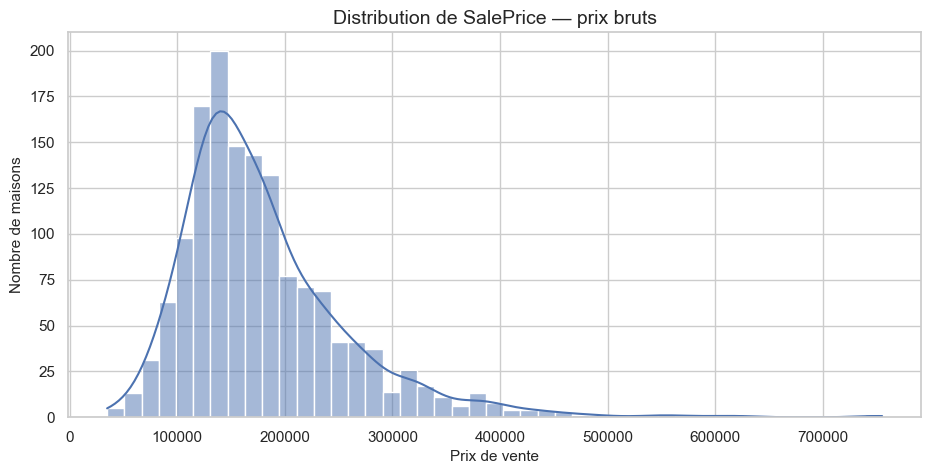

> **Interprétation :** Les prix sont asymétriques à droite : quelques maisons très chères tirent la distribution vers le haut. Le prix médian est **$163,000**, alors que la moyenne est **$180,921**. Cette différence confirme que la distribution n'est pas parfaitement symétrique.

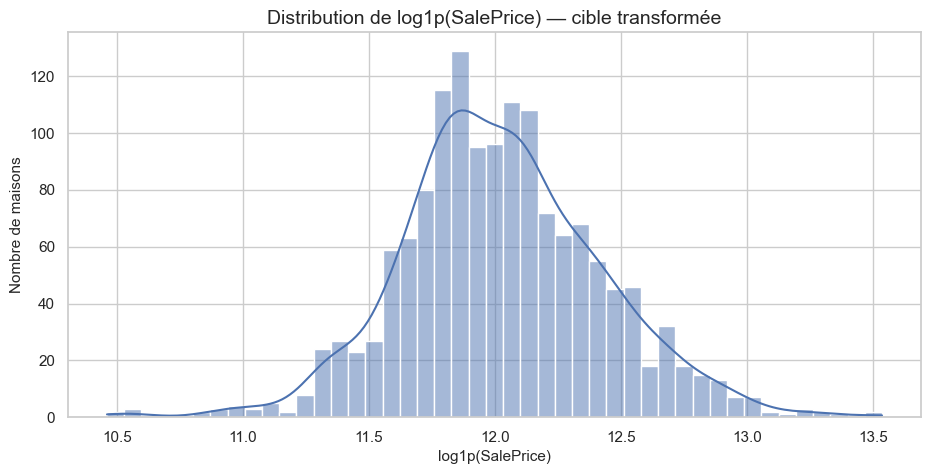

> **Interprétation :** Après `log1p`, la skewness passe de **1.883** à **0.121**. La distribution devient beaucoup plus proche d'une forme normale, ce qui aide les modèles linéaires comme Ridge, Lasso et ElasticNet.

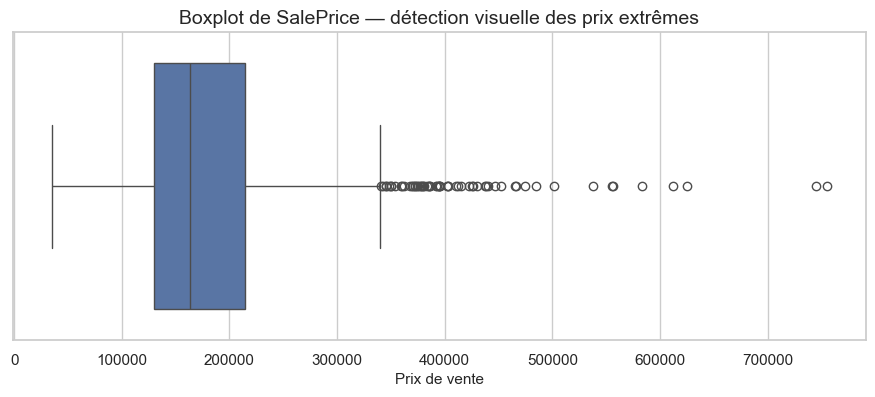

> **Interprétation :** Le boxplot confirme la présence de prix très élevés. Ces valeurs ne sont pas forcément des erreurs : elles peuvent représenter des maisons réellement luxueuses. Il faut donc éviter de supprimer les outliers sans justification métier.

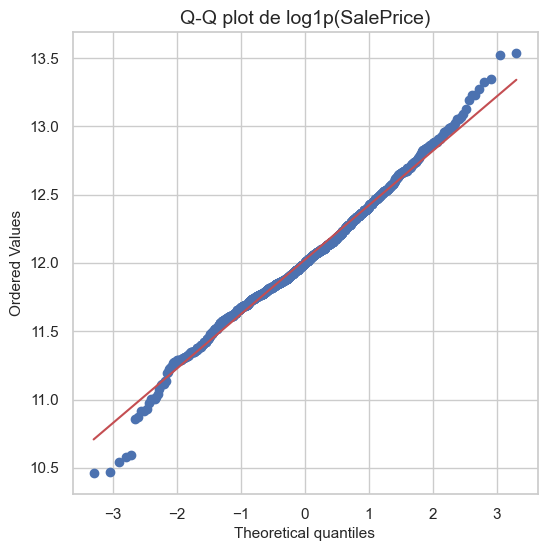

> **Interprétation :** Le Q-Q plot montre que la cible log-transformée suit mieux une distribution normale au centre, avec quelques écarts aux extrémités. C'est normal dans un problème immobilier : les biens très chers restent particuliers.

In [5]:
target = train_raw[TARGET].copy()
log_target = np.log1p(target)

price_stats = target.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).to_frame('SalePrice')
price_stats['SalePrice'] = price_stats['SalePrice'].map(lambda x: f'{x:,.0f}')
display(price_stats)

skew_raw = target.skew()
skew_log = log_target.skew()

print(f'Skewness avant log : {skew_raw:.3f}')
print(f'Skewness après log : {skew_log:.3f}')

plt.figure(figsize=(11, 5))
sns.histplot(target, bins=45, kde=True)
plt.title('Distribution de SalePrice — prix bruts')
plt.xlabel('Prix de vente')
plt.ylabel('Nombre de maisons')
plt.show()

interpretation(
    f"Les prix sont asymétriques à droite : quelques maisons très chères tirent la distribution vers le haut. "
    f"Le prix médian est **{money(target.median())}**, alors que la moyenne est **{money(target.mean())}**. "
    "Cette différence confirme que la distribution n'est pas parfaitement symétrique."
)

plt.figure(figsize=(11, 5))
sns.histplot(log_target, bins=45, kde=True)
plt.title('Distribution de log1p(SalePrice) — cible transformée')
plt.xlabel('log1p(SalePrice)')
plt.ylabel('Nombre de maisons')
plt.show()

interpretation(
    f"Après `log1p`, la skewness passe de **{skew_raw:.3f}** à **{skew_log:.3f}**. "
    "La distribution devient beaucoup plus proche d'une forme normale, ce qui aide les modèles linéaires comme Ridge, Lasso et ElasticNet."
)

plt.figure(figsize=(11, 4))
sns.boxplot(x=target)
plt.title('Boxplot de SalePrice — détection visuelle des prix extrêmes')
plt.xlabel('Prix de vente')
plt.show()

interpretation(
    "Le boxplot confirme la présence de prix très élevés. Ces valeurs ne sont pas forcément des erreurs : "
    "elles peuvent représenter des maisons réellement luxueuses. Il faut donc éviter de supprimer les outliers sans justification métier."
)

plt.figure(figsize=(6, 6))
stats.probplot(log_target, dist='norm', plot=plt)
plt.title('Q-Q plot de log1p(SalePrice)')
plt.show()

interpretation(
    "Le Q-Q plot montre que la cible log-transformée suit mieux une distribution normale au centre, "
    "avec quelques écarts aux extrémités. C'est normal dans un problème immobilier : les biens très chers restent particuliers."
)

## 6. Analyse des valeurs manquantes

Les valeurs manquantes sont très importantes ici, car dans ce dataset elles veulent souvent dire :

- pas de garage ;
- pas de sous-sol ;
- pas de piscine ;
- pas de cheminée ;
- pas d'allée.

Donc on ne doit pas tout remplacer aveuglément par la moyenne.

Valeurs manquantes — train


,dataset,missing_count,missing_percent,dtype
PoolQC,train,1453,99.520,str
MiscFeature,train,1406,96.300,str
Alley,train,1369,93.770,str
Fence,train,1179,80.750,str
MasVnrType,train,872,59.730,str
FireplaceQu,train,690,47.260,str
LotFrontage,train,259,17.740,float64
GarageType,train,81,5.550,str
GarageYrBlt,train,81,5.550,float64
GarageFinish,train,81,5.550,str


Valeurs manquantes — test


,dataset,missing_count,missing_percent,dtype
PoolQC,test,1456,99.790,str
MiscFeature,test,1408,96.500,str
Alley,test,1352,92.670,str
Fence,test,1169,80.120,str
MasVnrType,test,894,61.270,str
FireplaceQu,test,730,50.030,str
LotFrontage,test,227,15.560,float64
GarageQual,test,78,5.350,str
GarageCond,test,78,5.350,str
GarageYrBlt,test,78,5.350,float64


,train_missing_%,test_missing_%,max_missing_%
PoolQC,99.520,99.790,99.790
MiscFeature,96.300,96.500,96.500
Alley,93.770,92.670,93.770
Fence,80.750,80.120,80.750
MasVnrType,59.730,61.270,61.270
FireplaceQu,47.260,50.030,50.030
LotFrontage,17.740,15.560,17.740
GarageType,5.550,5.210,5.550
GarageYrBlt,5.550,5.350,5.550
GarageFinish,5.550,5.350,5.550


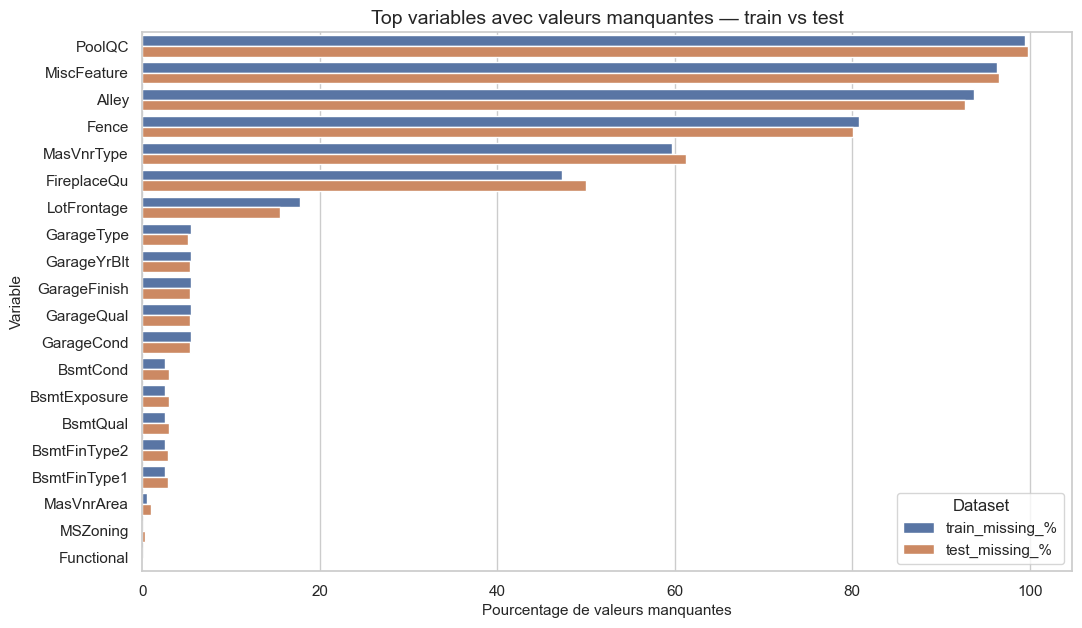

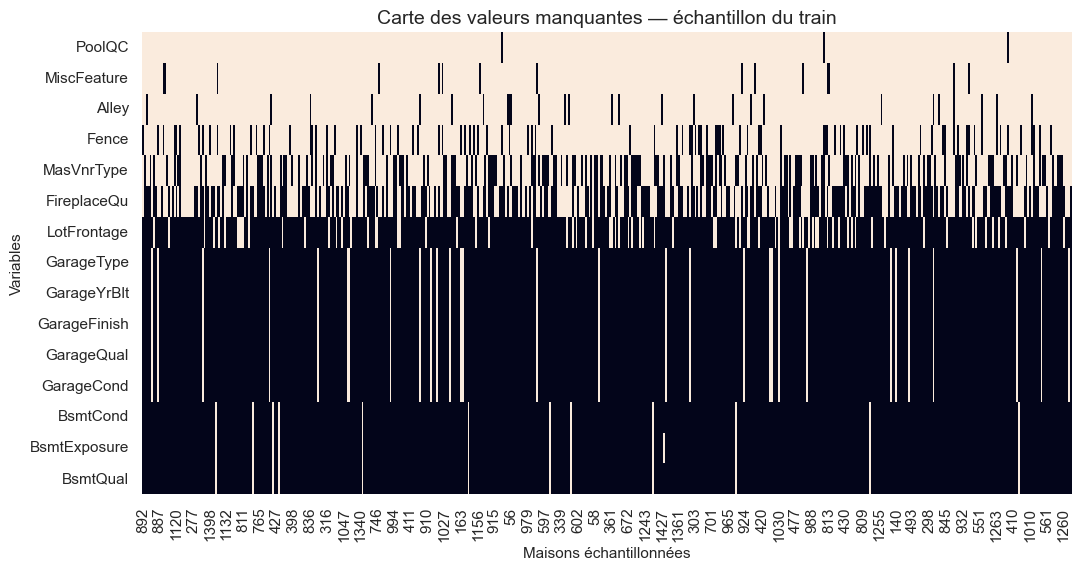

> **Interprétation :** Les variables les plus incomplètes sont : **PoolQC, MiscFeature, Alley, Fence, MasVnrType, FireplaceQu**. Dans House Prices, beaucoup de `NaN` sont informatifs : par exemple `PoolQC` manquant signifie souvent qu'il n'y a pas de piscine, et `GarageType` manquant signifie souvent qu'il n'y a pas de garage. C'est pour cela que le preprocessing remplace certaines valeurs par `None` plutôt que par une moyenne.

In [6]:
def missing_table(df, name):
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    out = pd.DataFrame({
        'dataset': name,
        'missing_count': miss,
        'missing_percent': 100 * miss / len(df),
        'dtype': df[miss.index].dtypes.astype(str)
    })
    return out

missing_train = missing_table(train_raw, 'train')
missing_test = missing_table(test_raw, 'test')

print('Valeurs manquantes — train')
display(missing_train.round(2))

print('Valeurs manquantes — test')
display(missing_test.round(2))

missing_compare = (
    pd.concat([
        missing_train[['missing_percent']].rename(columns={'missing_percent': 'train_missing_%'}),
        missing_test[['missing_percent']].rename(columns={'missing_percent': 'test_missing_%'}),
    ], axis=1)
    .fillna(0)
)
missing_compare['max_missing_%'] = missing_compare.max(axis=1)
missing_compare = missing_compare.sort_values('max_missing_%', ascending=False)

display(missing_compare.round(2).head(25))

if not missing_compare.empty:
    plot_data = missing_compare.head(20)[['train_missing_%', 'test_missing_%']].reset_index().rename(columns={'index': 'variable'})
    plot_long = plot_data.melt(id_vars='variable', var_name='dataset', value_name='missing_percent')

    plt.figure(figsize=(12, 7))
    sns.barplot(data=plot_long, y='variable', x='missing_percent', hue='dataset')
    plt.title('Top variables avec valeurs manquantes — train vs test')
    plt.xlabel('Pourcentage de valeurs manquantes')
    plt.ylabel('Variable')
    plt.legend(title='Dataset')
    plt.show()

    top_missing_cols = missing_compare.head(15).index.tolist()
    sample_missing = train_raw[top_missing_cols].isna().astype(int).sample(
        min(500, len(train_raw)), random_state=RANDOM_STATE
    )
    plt.figure(figsize=(12, 6))
    sns.heatmap(sample_missing.T, cbar=False)
    plt.title('Carte des valeurs manquantes — échantillon du train')
    plt.xlabel('Maisons échantillonnées')
    plt.ylabel('Variables')
    plt.show()

high_missing = missing_compare[missing_compare['max_missing_%'] > 30].index.tolist()

interpretation(
    f"Les variables les plus incomplètes sont : **{', '.join(high_missing[:8]) if high_missing else 'aucune variable au-dessus de 30%'}**. "
    "Dans House Prices, beaucoup de `NaN` sont informatifs : par exemple `PoolQC` manquant signifie souvent qu'il n'y a pas de piscine, "
    "et `GarageType` manquant signifie souvent qu'il n'y a pas de garage. C'est pour cela que le preprocessing remplace certaines valeurs par `None` plutôt que par une moyenne."
)

### 6.1 Interprétation métier des valeurs manquantes

Cette table sert à justifier les choix du notebook de preprocessing.

In [7]:
missing_meaning = pd.DataFrame({
    'Groupe': [
        'Piscine', 'Divers', 'Allée', 'Clôture', 'Cheminée',
        'Garage', 'Sous-sol', 'Maçonnerie', 'Lot frontage'
    ],
    'Variables typiques': [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
        'GarageType, GarageYrBlt, GarageFinish, GarageQual, GarageCond',
        'BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2',
        'MasVnrType, MasVnrArea', 'LotFrontage'
    ],
    'Interprétation probable': [
        'Pas de piscine', 'Pas de caractéristique diverse', 'Pas d’accès par allée', 'Pas de clôture', 'Pas de cheminée',
        'Pas de garage', 'Pas de sous-sol', 'Pas de placage en maçonnerie',
        'Valeur manquante à imputer intelligemment, souvent par quartier'
    ],
    'Traitement logique': [
        'Remplacer par None', 'Remplacer par None', 'Remplacer par None', 'Remplacer par None', 'Remplacer par None',
        'None pour les catégories, 0 pour les surfaces/années si absence',
        'None pour les catégories, 0 pour les surfaces si absence',
        'None ou 0 selon la variable', 'Médiane par Neighborhood'
    ]
})

display(missing_meaning)

interpretation(
    "Cette distinction est importante : une valeur manquante peut être une information métier, pas seulement un problème technique. "
    "Le bon preprocessing doit respecter cette signification."
)

,Groupe,Variables typiques,Interprétation probable,Traitement logique
0,Piscine,PoolQC,Pas de piscine,Remplacer par None
1,Divers,MiscFeature,Pas de caractéristique diverse,Remplacer par None
2,Allée,Alley,Pas d’accès par allée,Remplacer par None
3,Clôture,Fence,Pas de clôture,Remplacer par None
4,Cheminée,FireplaceQu,Pas de cheminée,Remplacer par None
5,Garage,"GarageType, GarageYrBlt, GarageFinish, GarageQ...",Pas de garage,"None pour les catégories, 0 pour les surfaces/..."
6,Sous-sol,"BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1...",Pas de sous-sol,"None pour les catégories, 0 pour les surfaces ..."
7,Maçonnerie,"MasVnrType, MasVnrArea",Pas de placage en maçonnerie,None ou 0 selon la variable
8,Lot frontage,LotFrontage,"Valeur manquante à imputer intelligemment, sou...",Médiane par Neighborhood


> **Interprétation :** Cette distinction est importante : une valeur manquante peut être une information métier, pas seulement un problème technique. Le bon preprocessing doit respecter cette signification.

## 7. Corrélations numériques avec `SalePrice`

On cherche les variables numériques qui ont le lien le plus fort avec le prix.

,corrélation avec SalePrice
OverallQual,0.791
GrLivArea,0.709
GarageCars,0.640
GarageArea,0.623
TotalBsmtSF,0.614
1stFlrSF,0.606
FullBath,0.561
TotRmsAbvGrd,0.534
YearBuilt,0.523
YearRemodAdd,0.507


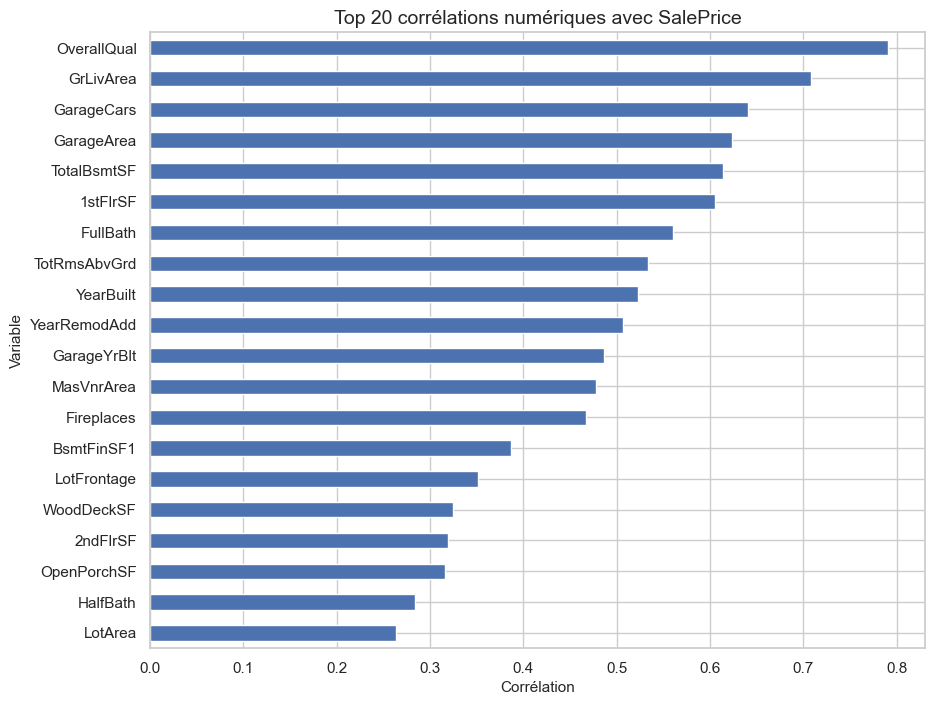

> **Interprétation :** Les variables numériques les plus liées au prix sont **OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF**. Cela confirme que la qualité générale, la surface habitable, le garage, le sous-sol et l'année de construction sont des signaux majeurs.

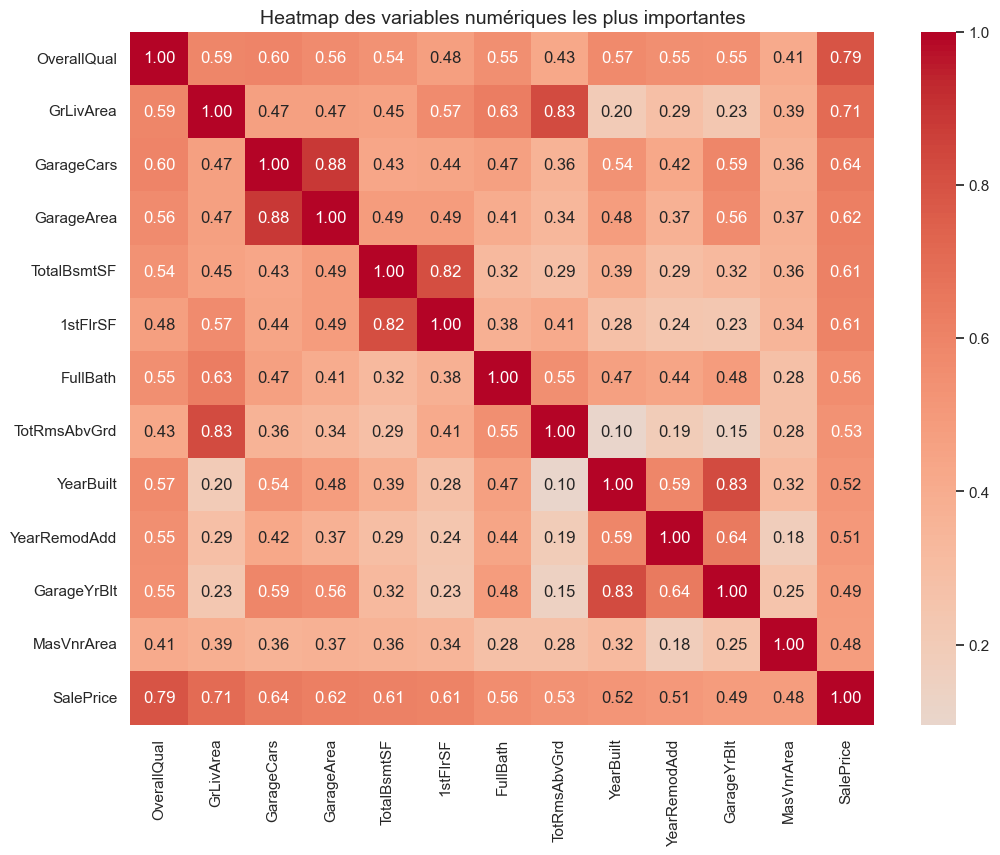

> **Interprétation :** La heatmap montre aussi les corrélations entre features. Par exemple, `GarageCars` et `GarageArea` sont souvent très liées. Cela explique pourquoi les modèles régularisés comme Ridge/Lasso sont utiles : ils gèrent mieux les variables redondantes.

In [8]:
num_with_target = [c for c in numeric_cols if c in train_raw.columns] + [TARGET]
corr_saleprice = (
    train_raw[num_with_target]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(corr_saleprice.head(25).to_frame('corrélation avec SalePrice').round(3))

plt.figure(figsize=(10, 8))
corr_saleprice.head(20).sort_values().plot(kind='barh')
plt.title('Top 20 corrélations numériques avec SalePrice')
plt.xlabel('Corrélation')
plt.ylabel('Variable')
plt.show()

strongest_num = corr_saleprice.head(6).index.tolist()
interpretation(
    f"Les variables numériques les plus liées au prix sont **{', '.join(strongest_num)}**. "
    "Cela confirme que la qualité générale, la surface habitable, le garage, le sous-sol et l'année de construction sont des signaux majeurs."
)

# Heatmap des variables les plus corrélées
heatmap_cols = corr_saleprice.head(12).index.tolist() + [TARGET]
plt.figure(figsize=(12, 9))
sns.heatmap(train_raw[heatmap_cols].corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap des variables numériques les plus importantes')
plt.show()

interpretation(
    "La heatmap montre aussi les corrélations entre features. Par exemple, `GarageCars` et `GarageArea` sont souvent très liées. "
    "Cela explique pourquoi les modèles régularisés comme Ridge/Lasso sont utiles : ils gèrent mieux les variables redondantes."
)

## 8. Relations visuelles clés avec le prix

Maintenant on visualise les relations les plus importantes.  
Ces plots sont plus parlants qu'une simple corrélation.

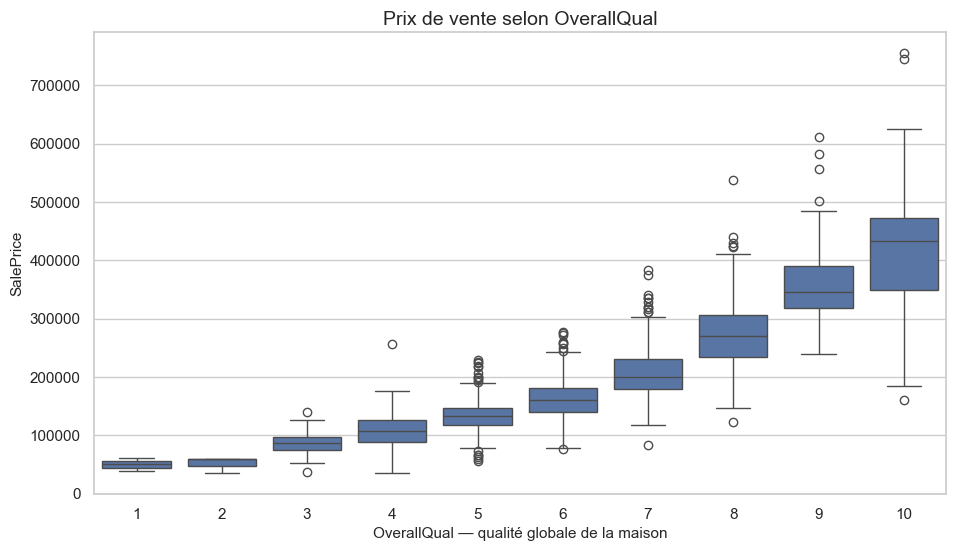

> **Interprétation :** `OverallQual` est un signal extrêmement fort : plus la qualité globale augmente, plus le prix médian augmente. C'est pour cela que le feature engineering crée des interactions entre qualité et surface, comme `OverallQual_TotalSF`.

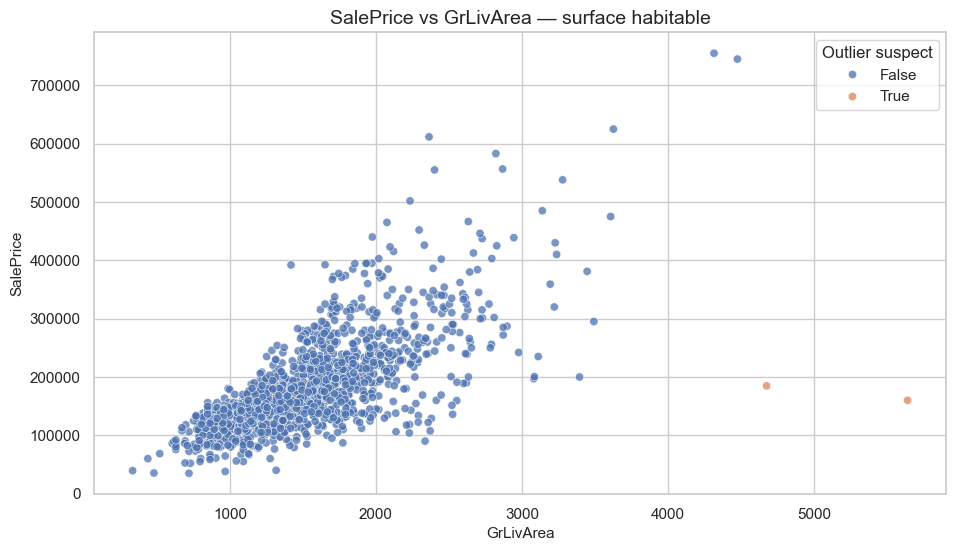

> **Interprétation :** La relation entre surface habitable et prix est clairement positive. Mais on observe **2 points suspects** : très grande surface mais prix relativement bas. Ces points peuvent perturber les modèles, donc le pipeline les retire avant l'entraînement.

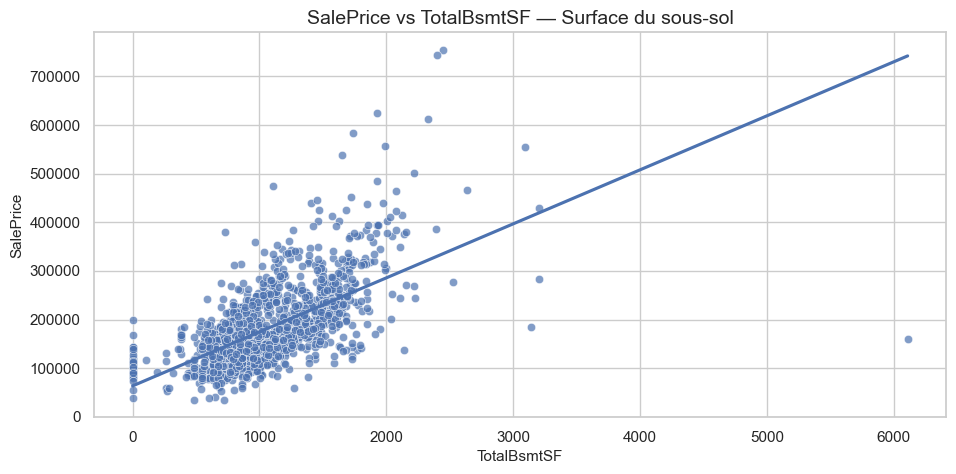

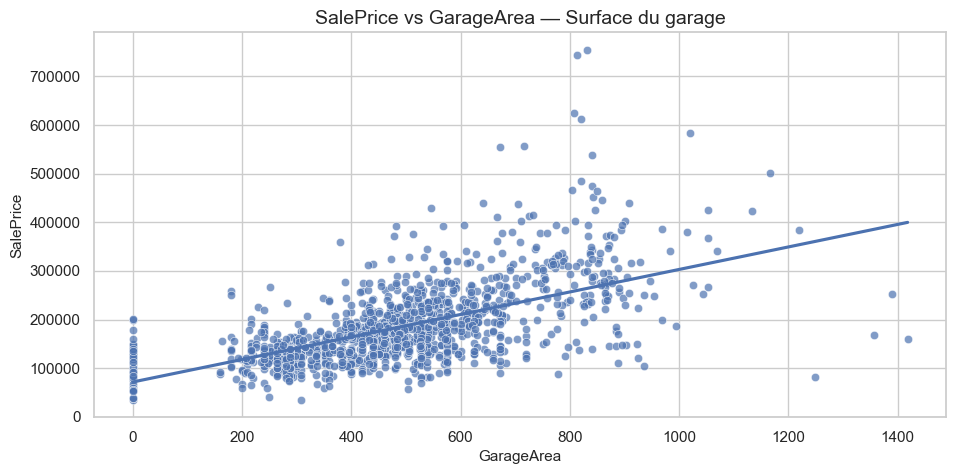

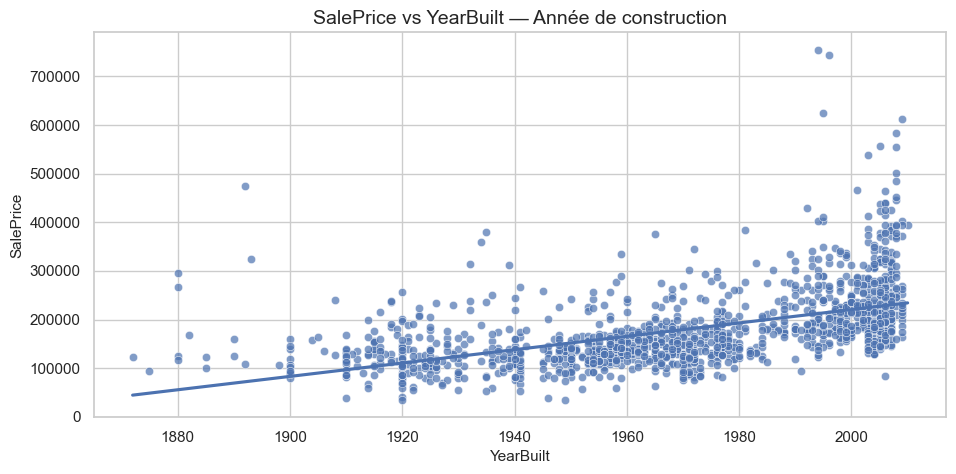

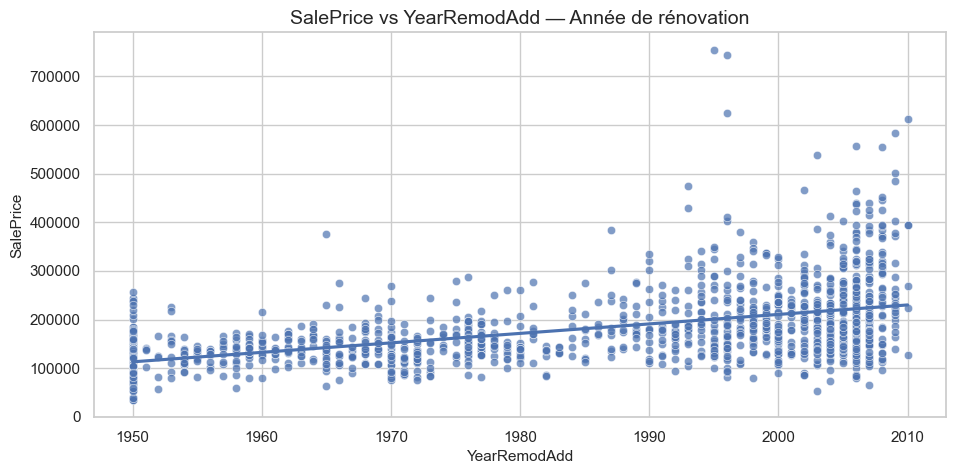

> **Interprétation :** Les surfaces (`TotalBsmtSF`, `GarageArea`) ont une relation positive avec le prix. Les années de construction/rénovation montrent que les maisons plus récentes ou rénovées tendent à être plus chères. Cela justifie les features d'âge : `HouseAge`, `RemodAge`, `IsRemodeled`, etc.

In [9]:
# 8.1 OverallQual : souvent la variable la plus forte
plt.figure(figsize=(11, 6))
sns.boxplot(data=train_raw, x='OverallQual', y=TARGET)
plt.title('Prix de vente selon OverallQual')
plt.xlabel('OverallQual — qualité globale de la maison')
plt.ylabel('SalePrice')
plt.show()

qual_medians = train_raw.groupby('OverallQual')[TARGET].median().sort_index()
quality_gain = qual_medians.iloc[-1] / qual_medians.iloc[0] if qual_medians.iloc[0] > 0 else np.nan

interpretation(
    "`OverallQual` est un signal extrêmement fort : plus la qualité globale augmente, plus le prix médian augmente. "
    "C'est pour cela que le feature engineering crée des interactions entre qualité et surface, comme `OverallQual_TotalSF`."
)

# 8.2 Surface habitable
outlier_mask_grliv = (train_raw['GrLivArea'] > 4000) & (train_raw[TARGET] < 300_000)

plt.figure(figsize=(11, 6))
sns.scatterplot(data=train_raw, x='GrLivArea', y=TARGET, hue=outlier_mask_grliv, alpha=0.75)
plt.title('SalePrice vs GrLivArea — surface habitable')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.legend(title='Outlier suspect')
plt.show()

interpretation(
    f"La relation entre surface habitable et prix est clairement positive. "
    f"Mais on observe **{int(outlier_mask_grliv.sum())} points suspects** : très grande surface mais prix relativement bas. "
    "Ces points peuvent perturber les modèles, donc le pipeline les retire avant l'entraînement."
)

# 8.3 Sous-sol, garage, année de construction
for col, titre in [
    ('TotalBsmtSF', 'Surface du sous-sol'),
    ('GarageArea', 'Surface du garage'),
    ('YearBuilt', 'Année de construction'),
    ('YearRemodAdd', 'Année de rénovation')
]:
    plt.figure(figsize=(11, 5))
    sns.scatterplot(data=train_raw, x=col, y=TARGET, alpha=0.7)
    sns.regplot(data=train_raw, x=col, y=TARGET, scatter=False, ci=None)
    plt.title(f'SalePrice vs {col} — {titre}')
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.show()

interpretation(
    "Les surfaces (`TotalBsmtSF`, `GarageArea`) ont une relation positive avec le prix. "
    "Les années de construction/rénovation montrent que les maisons plus récentes ou rénovées tendent à être plus chères. "
    "Cela justifie les features d'âge : `HouseAge`, `RemodAge`, `IsRemodeled`, etc."
)

## 9. Effet des quartiers (`Neighborhood`)

`Neighborhood` est une variable catégorielle, mais elle est souvent l'une des plus puissantes dans cette compétition.

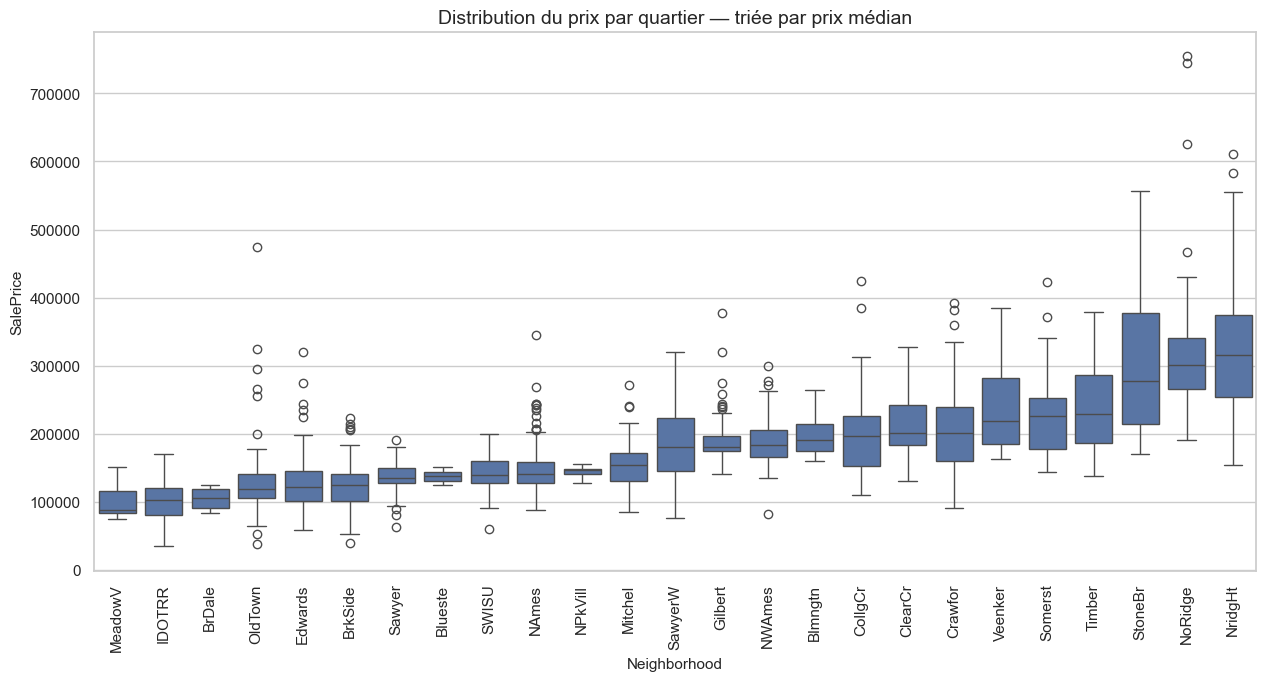

,count,mean,median,std
Neighborhood,,,,
NridgHt,77,"316,271.000","315,000.000","96,393.000"
NoRidge,41,"335,295.000","301,500.000","121,413.000"
StoneBr,25,"310,499.000","278,000.000","112,970.000"
Timber,38,"242,247.000","228,475.000","64,846.000"
Somerst,86,"225,380.000","225,500.000","56,178.000"
Veenker,11,"238,773.000","218,000.000","72,369.000"
Crawfor,51,"210,625.000","200,624.000","68,866.000"
ClearCr,28,"212,565.000","200,250.000","50,232.000"
CollgCr,150,"197,966.000","197,200.000","51,404.000"


> **Interprétation :** Le quartier le plus cher selon le prix médian est **NridgHt**, tandis que le moins cher est **MeadowV**. Le ratio entre leurs prix médians est d'environ **3.58**. Donc `Neighborhood` doit être traité avec attention : one-hot encoding, frequency encoding et target encoding peuvent apporter beaucoup d'information.

,train_%,test_%,abs_diff_%
Neighborhood,,,
NAmes,15.410,14.940,0.470
CollgCr,10.270,8.020,2.250
OldTown,7.740,8.640,0.900
Edwards,6.850,6.440,0.410
Somerst,5.890,6.580,0.690
Gilbert,5.410,5.890,0.480
NridgHt,5.270,6.100,0.830
Sawyer,5.070,5.280,0.210
NWAmes,5.000,3.980,1.020


<Figure size 1400x600 with 0 Axes>

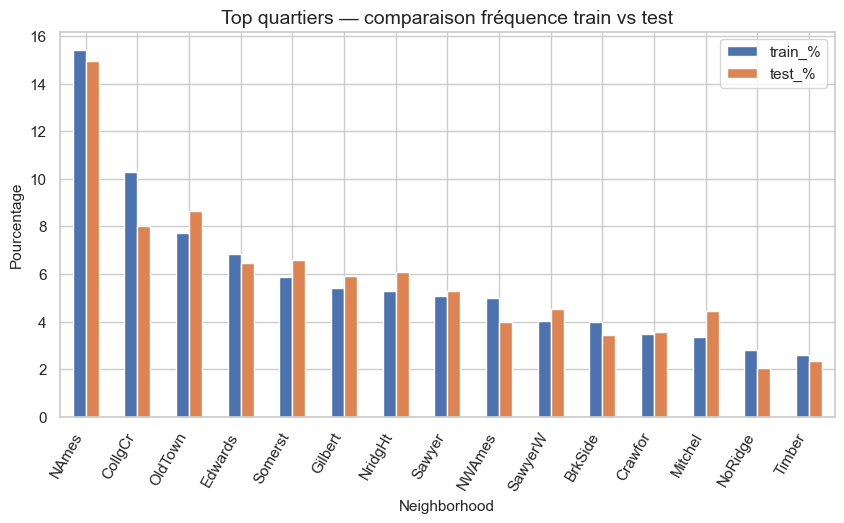

> **Interprétation :** Comparer la distribution des quartiers entre train et test permet de vérifier que le test ressemble globalement au train. Si un quartier est beaucoup plus présent dans le test, le modèle doit bien généraliser pour cette catégorie.

In [ ]:
neigh_order = train_raw.groupby('Neighborhood')[TARGET].median().sort_values().index

plt.figure(figsize=(15, 7))
sns.boxplot(data=train_raw, x='Neighborhood', y=TARGET, order=neigh_order)
plt.xticks(rotation=90)
plt.title('Distribution du prix par quartier — triée par prix médian')
plt.xlabel('Neighborhood')
plt.ylabel('SalePrice')
plt.show()

neigh_summary = (
    train_raw.groupby('Neighborhood')[TARGET]
    .agg(['count', 'mean', 'median', 'std'])
    .sort_values('median', ascending=False)
)

display(neigh_summary.round(0))

best_neigh = neigh_summary.index[0]
worst_neigh = neigh_summary.index[-1]
ratio_neigh = neigh_summary.loc[best_neigh, 'median'] / neigh_summary.loc[worst_neigh, 'median']

interpretation(
    f"Le quartier le plus cher selon le prix médian est **{best_neigh}**, tandis que le moins cher est **{worst_neigh}**. "
    f"Le ratio entre leurs prix médians est d'environ **{ratio_neigh:.2f}**. "
    "Donc `Neighborhood` doit être traité avec attention : one-hot encoding, frequency encoding et target encoding peuvent apporter beaucoup d'information."
)

# Fréquence des quartiers dans train et test
train_neigh_pct = train_raw['Neighborhood'].value_counts(normalize=True).rename('train_%') * 100
test_neigh_pct = test_raw['Neighborhood'].value_counts(normalize=True).rename('test_%') * 100
neigh_dist = pd.concat([train_neigh_pct, test_neigh_pct], axis=1).fillna(0)
neigh_dist['abs_diff_%'] = (neigh_dist['train_%'] - neigh_dist['test_%']).abs()
neigh_dist = neigh_dist.sort_values('train_%', ascending=False)

display(neigh_dist.round(2).head(15))

plt.figure(figsize=(14, 6))
neigh_dist[['train_%', 'test_%']].head(15).plot(kind='bar')
plt.title('Top quartiers — comparaison fréquence train vs test')
plt.xlabel('Neighborhood')
plt.ylabel('Pourcentage')
plt.xticks(rotation=60, ha='right')
plt.show()

interpretation(
    "Comparer la distribution des quartiers entre train et test permet de vérifier que le test ressemble globalement au train. "
    "Si un quartier est beaucoup plus présent dans le test, le modèle doit bien généraliser pour cette catégorie."
)

## 10. Variables catégorielles importantes

On analyse plusieurs catégories liées à la qualité, au zoning et aux conditions de vente.

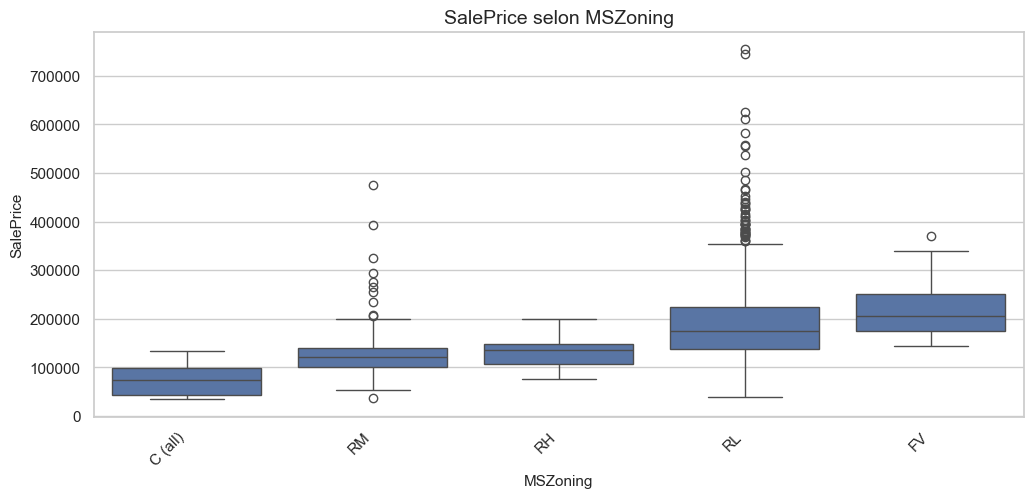

,count,median,mean
MSZoning,,,
FV,65,"205,950.000","214,014.000"
RL,1151,"174,000.000","191,005.000"
RH,16,"136,500.000","131,558.000"
RM,218,"120,500.000","126,317.000"
C (all),10,"74,700.000","74,528.000"


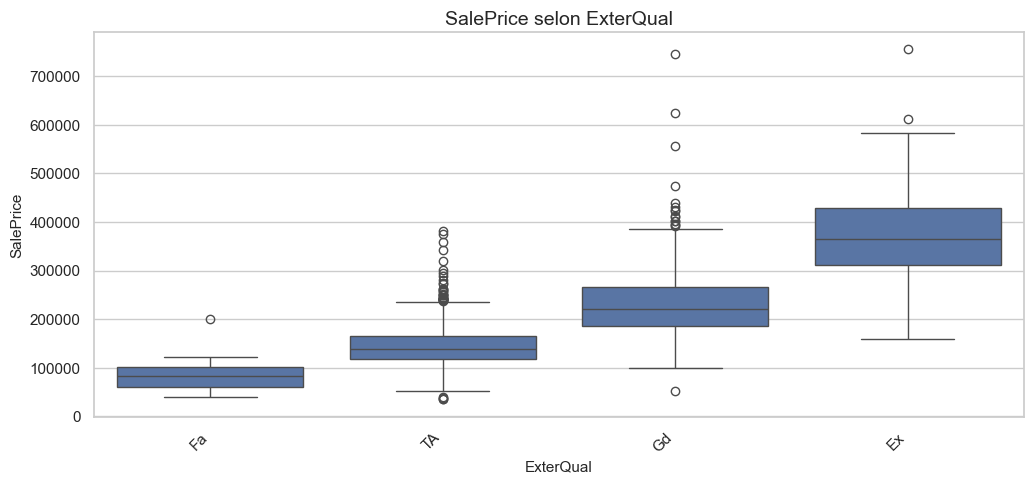

,count,median,mean
ExterQual,,,
Ex,52,"364,606.000","367,361.000"
Gd,488,"220,000.000","231,634.000"
TA,906,"139,450.000","144,341.000"
Fa,14,"82,250.000","87,985.000"


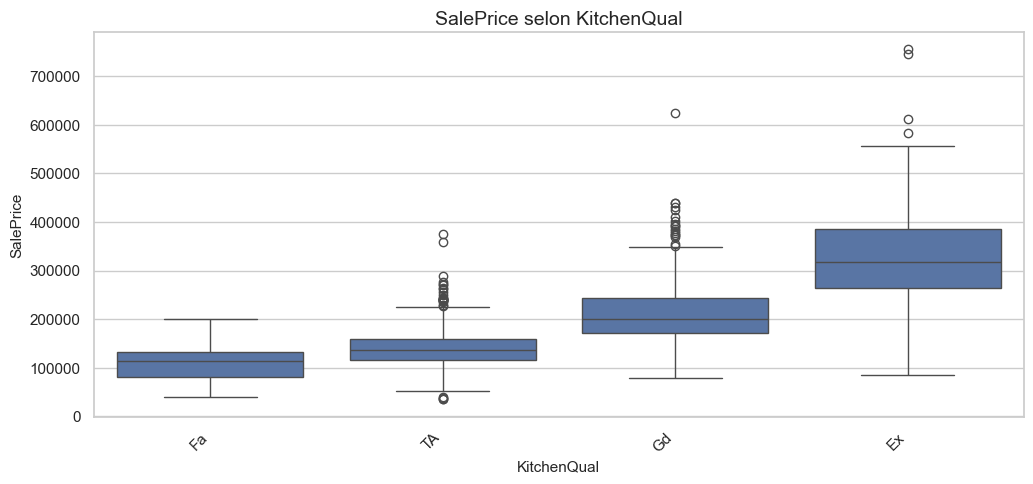

,count,median,mean
KitchenQual,,,
Ex,100,"316,750.000","328,555.000"
Gd,586,"201,400.000","212,116.000"
TA,735,"137,000.000","139,963.000"
Fa,39,"115,000.000","105,565.000"


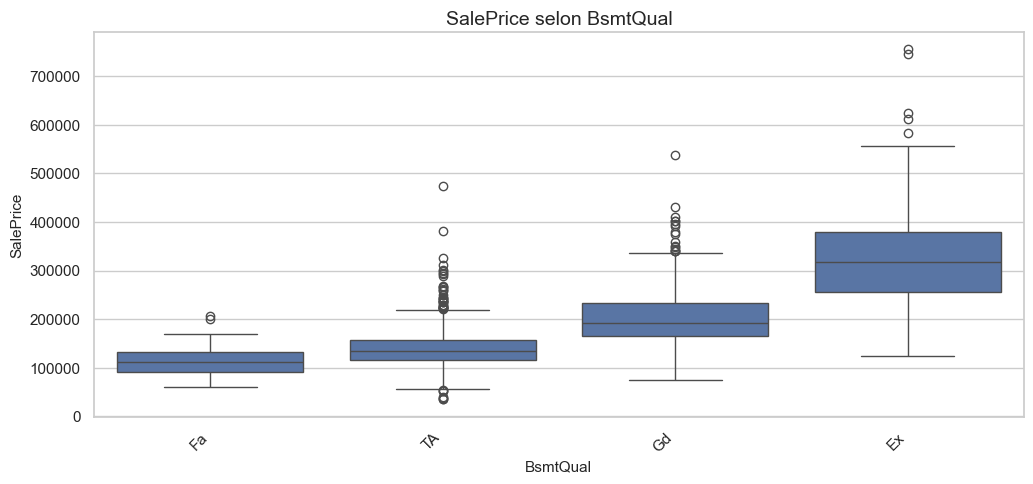

,count,median,mean
BsmtQual,,,
Ex,121,"318,000.000","327,041.000"
Gd,618,"192,070.000","202,688.000"
TA,649,"135,500.000","140,760.000"
Fa,35,"112,000.000","115,692.000"


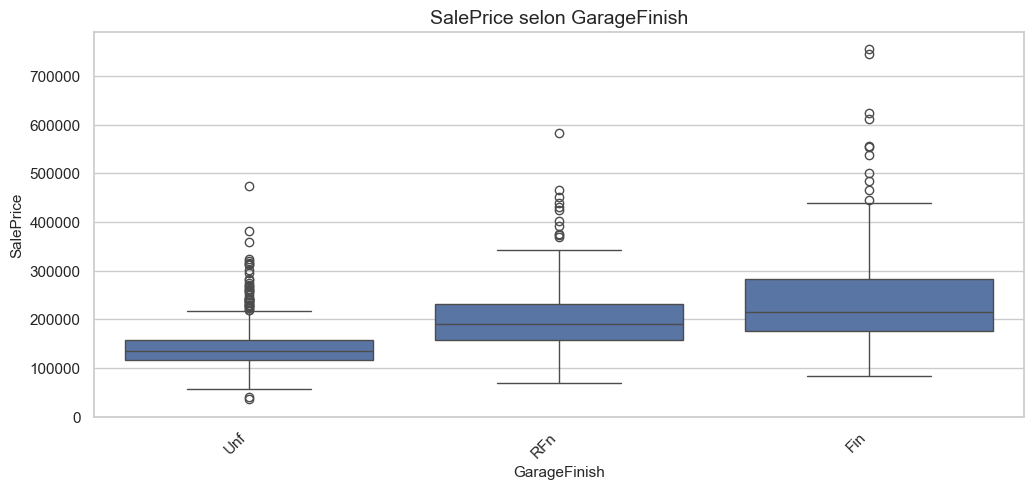

,count,median,mean
GarageFinish,,,
Fin,352,"215,000.000","240,053.000"
RFn,422,"190,000.000","202,069.000"
Unf,605,"135,000.000","142,156.000"


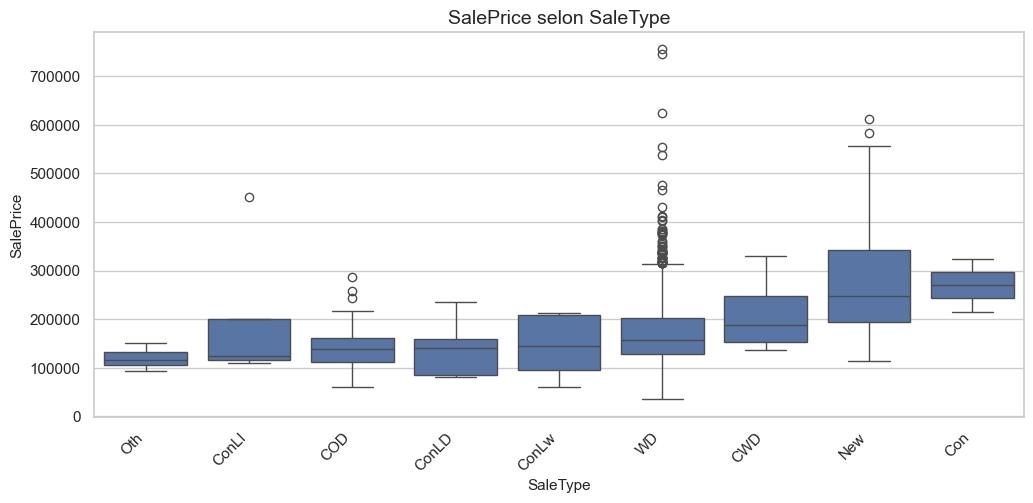

,count,median,mean
SaleType,,,
Con,2,"269,600.000","269,600.000"
New,122,"247,453.000","274,945.000"
CWD,4,"188,750.000","210,600.000"
WD,1267,"158,000.000","173,402.000"
ConLw,5,"144,000.000","143,700.000"
ConLD,9,"140,000.000","138,781.000"
COD,43,"139,000.000","143,973.000"
ConLI,5,"125,000.000","200,390.000"
Oth,3,"116,050.000","119,850.000"


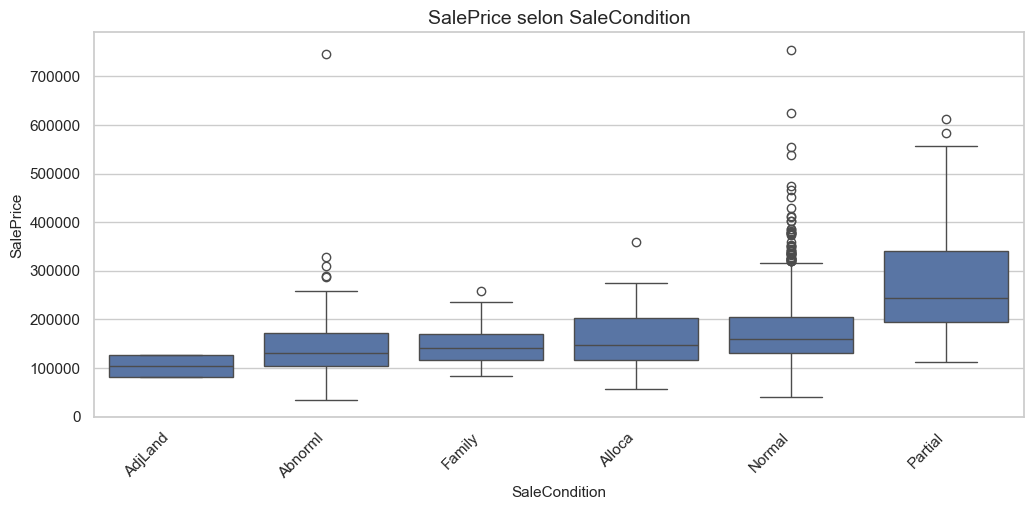

,count,median,mean
SaleCondition,,,
Partial,125,"244,600.000","272,292.000"
Normal,1198,"160,000.000","175,202.000"
Alloca,12,"148,145.000","167,377.000"
Family,20,"140,500.000","149,600.000"
Abnorml,101,"130,000.000","146,527.000"
AdjLand,4,"104,000.000","104,125.000"


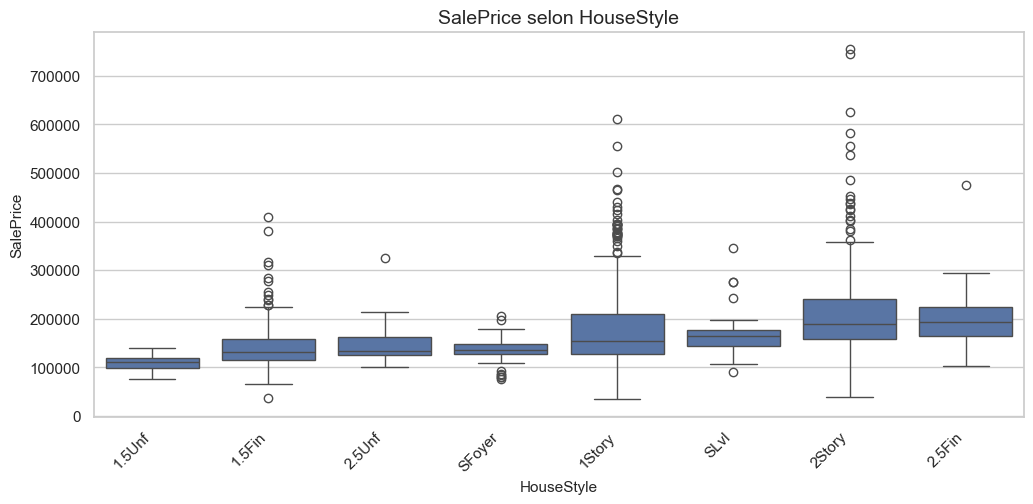

,count,median,mean
HouseStyle,,,
2.5Fin,8,"194,000.000","220,000.000"
2Story,445,"190,000.000","210,052.000"
SLvl,65,"164,500.000","166,703.000"
1Story,726,"154,750.000","175,985.000"
SFoyer,37,"135,960.000","135,074.000"
2.5Unf,11,"133,900.000","157,355.000"
1.5Fin,154,"132,000.000","143,117.000"
1.5Unf,14,"111,250.000","110,150.000"


> **Interprétation :** Les variables de qualité (`ExterQual`, `KitchenQual`, `BsmtQual`) ont un ordre naturel : Poor < Fair < Typical < Good < Excellent. C'est pour cela que le preprocessing utilise un encodage ordinal pour ces colonnes au lieu de les traiter comme de simples catégories sans ordre.

In [11]:
important_categoricals = [
    'MSZoning', 'ExterQual', 'KitchenQual', 'BsmtQual',
    'GarageFinish', 'SaleType', 'SaleCondition', 'HouseStyle'
]
important_categoricals = [c for c in important_categoricals if c in train_raw.columns]

for col in important_categoricals:
    order = train_raw.groupby(col)[TARGET].median().sort_values().index
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=train_raw, x=col, y=TARGET, order=order)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'SalePrice selon {col}')
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.show()

    cat_summary = (
        train_raw.groupby(col)[TARGET]
        .agg(['count', 'median', 'mean'])
        .sort_values('median', ascending=False)
    )
    display(cat_summary.round(0))

interpretation(
    "Les variables de qualité (`ExterQual`, `KitchenQual`, `BsmtQual`) ont un ordre naturel : Poor < Fair < Typical < Good < Excellent. "
    "C'est pour cela que le preprocessing utilise un encodage ordinal pour ces colonnes au lieu de les traiter comme de simples catégories sans ordre."
)

## 11. Création de features temporaires pour comprendre le feature engineering

Ici, on crée quelques features seulement pour l'analyse EDA.  
Elles ne remplacent pas le vrai notebook de feature engineering, mais elles expliquent pourquoi ces idées sont utiles.

,corrélation avec SalePrice
TotalSF_EDA,0.782
TotalBathrooms_EDA,0.632
HouseAge_EDA,-0.523
RemodAge_EDA,-0.509
HasFireplace_EDA,0.472
HasGarage_EDA,0.237
TotalPorchSF_EDA,0.196
HasBsmt_EDA,0.153
HasPool_EDA,0.094
IsRemodeled_EDA,-0.022


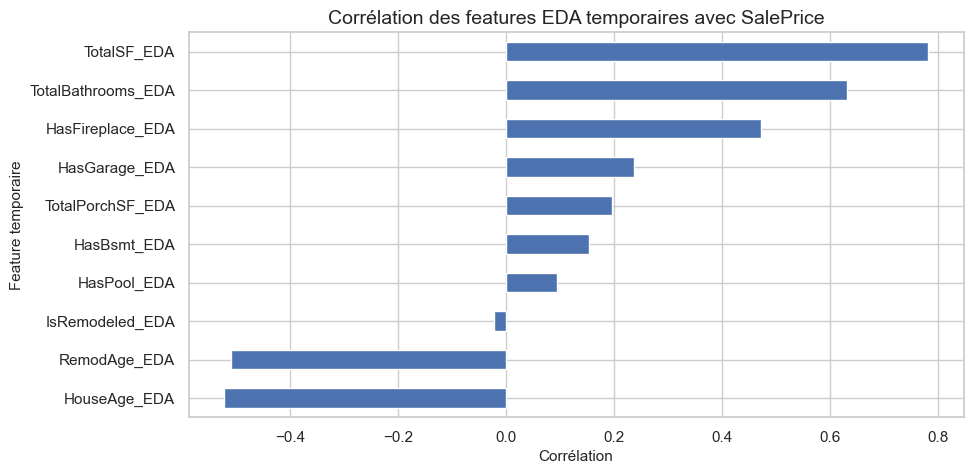

> **Interprétation :** `TotalSF_EDA` et `TotalBathrooms_EDA` sont souvent plus informatives que plusieurs colonnes isolées. Cela montre l'intérêt de créer des features agrégées : elles résument mieux la valeur réelle d'une maison.

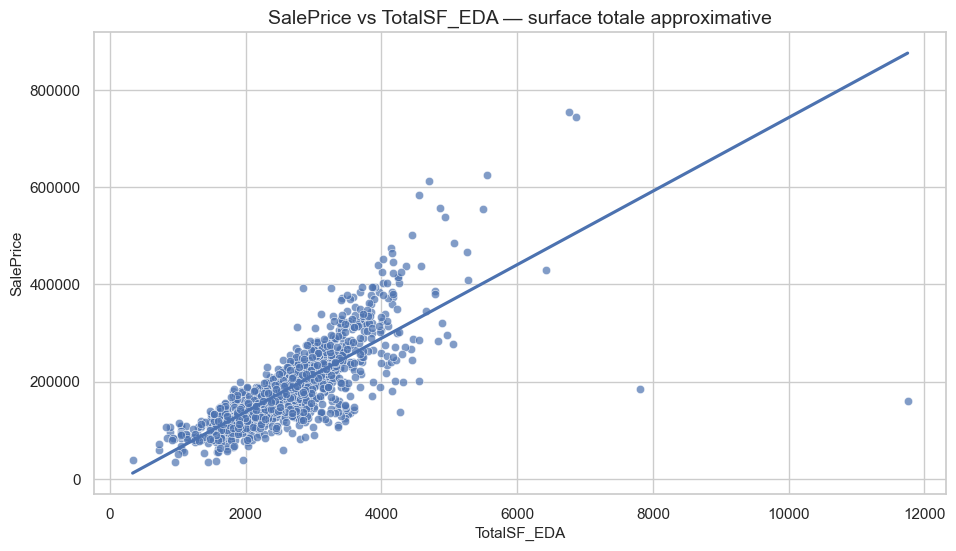

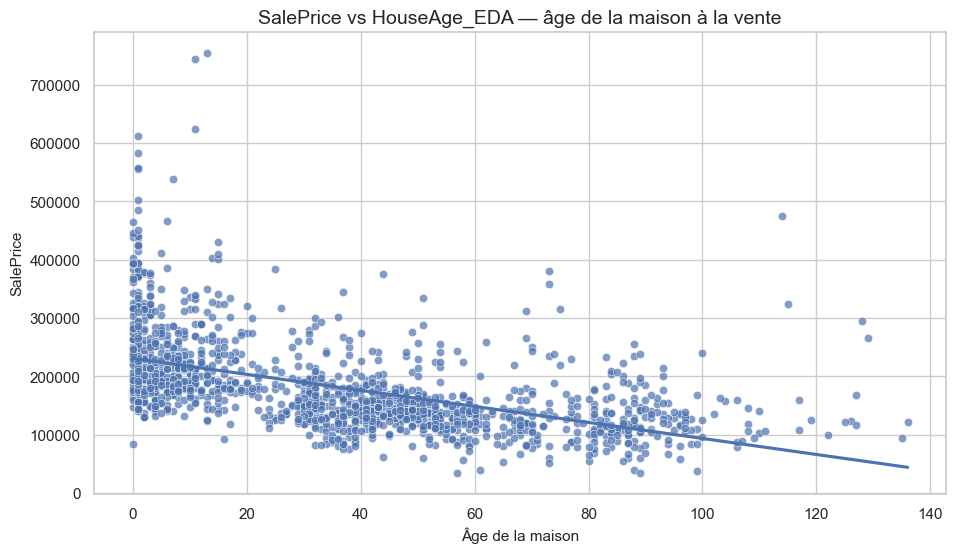

> **Interprétation :** La surface totale a une relation positive avec le prix. À l'inverse, l'âge de la maison tend souvent à avoir une relation négative : les maisons plus anciennes sont en moyenne moins chères, sauf exceptions liées au quartier, au style ou aux rénovations.

In [12]:
eda = train_raw.copy()

# Features de surface
eda['TotalSF_EDA'] = eda.get('TotalBsmtSF', 0).fillna(0) + eda.get('1stFlrSF', 0).fillna(0) + eda.get('2ndFlrSF', 0).fillna(0)
eda['TotalPorchSF_EDA'] = (
    eda.get('OpenPorchSF', 0).fillna(0) + eda.get('EnclosedPorch', 0).fillna(0) +
    eda.get('3SsnPorch', 0).fillna(0) + eda.get('ScreenPorch', 0).fillna(0)
)

# Features de salle de bain
eda['TotalBathrooms_EDA'] = (
    eda.get('FullBath', 0).fillna(0) + 0.5 * eda.get('HalfBath', 0).fillna(0) +
    eda.get('BsmtFullBath', 0).fillna(0) + 0.5 * eda.get('BsmtHalfBath', 0).fillna(0)
)

# Features d'âge
eda['HouseAge_EDA'] = eda['YrSold'] - eda['YearBuilt']
eda['RemodAge_EDA'] = eda['YrSold'] - eda['YearRemodAdd']
eda['IsRemodeled_EDA'] = (eda['YearRemodAdd'] != eda['YearBuilt']).astype(int)

# Flags d'existence
eda['HasGarage_EDA'] = (eda.get('GarageArea', 0).fillna(0) > 0).astype(int)
eda['HasBsmt_EDA'] = (eda.get('TotalBsmtSF', 0).fillna(0) > 0).astype(int)
eda['HasFireplace_EDA'] = (eda.get('Fireplaces', 0).fillna(0) > 0).astype(int)
eda['HasPool_EDA'] = (eda.get('PoolArea', 0).fillna(0) > 0).astype(int)

new_eda_features = [
    'TotalSF_EDA', 'TotalPorchSF_EDA', 'TotalBathrooms_EDA',
    'HouseAge_EDA', 'RemodAge_EDA', 'IsRemodeled_EDA',
    'HasGarage_EDA', 'HasBsmt_EDA', 'HasFireplace_EDA', 'HasPool_EDA'
]

corr_new = eda[new_eda_features + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_new.to_frame('corrélation avec SalePrice').round(3))

plt.figure(figsize=(10, 5))
corr_new.sort_values().plot(kind='barh')
plt.title('Corrélation des features EDA temporaires avec SalePrice')
plt.xlabel('Corrélation')
plt.ylabel('Feature temporaire')
plt.show()

interpretation(
    "`TotalSF_EDA` et `TotalBathrooms_EDA` sont souvent plus informatives que plusieurs colonnes isolées. "
    "Cela montre l'intérêt de créer des features agrégées : elles résument mieux la valeur réelle d'une maison."
)

plt.figure(figsize=(11, 6))
sns.scatterplot(data=eda, x='TotalSF_EDA', y=TARGET, alpha=0.7)
sns.regplot(data=eda, x='TotalSF_EDA', y=TARGET, scatter=False, ci=None)
plt.title('SalePrice vs TotalSF_EDA — surface totale approximative')
plt.xlabel('TotalSF_EDA')
plt.ylabel('SalePrice')
plt.show()

plt.figure(figsize=(11, 6))
sns.scatterplot(data=eda, x='HouseAge_EDA', y=TARGET, alpha=0.7)
sns.regplot(data=eda, x='HouseAge_EDA', y=TARGET, scatter=False, ci=None)
plt.title('SalePrice vs HouseAge_EDA — âge de la maison à la vente')
plt.xlabel('Âge de la maison')
plt.ylabel('SalePrice')
plt.show()

interpretation(
    "La surface totale a une relation positive avec le prix. À l'inverse, l'âge de la maison tend souvent à avoir une relation négative : "
    "les maisons plus anciennes sont en moyenne moins chères, sauf exceptions liées au quartier, au style ou aux rénovations."
)

## 12. Impact des flags : garage, sous-sol, cheminée, piscine

Ces variables binaires permettent de voir si la présence d'un élément change fortement le prix médian.

,feature,value,count,median,mean
0,HasGarage_EDA,0,81,"100,000.000","103,317.000"
1,HasGarage_EDA,1,1379,"167,500.000","185,480.000"
2,HasBsmt_EDA,0,37,"101,800.000","105,653.000"
3,HasBsmt_EDA,1,1423,"165,000.000","182,878.000"
4,HasFireplace_EDA,0,690,"135,000.000","141,331.000"
5,HasFireplace_EDA,1,770,"191,000.000","216,398.000"
6,HasPool_EDA,0,1453,"162,900.000","180,405.000"
7,HasPool_EDA,1,7,"235,000.000","288,139.000"
8,IsRemodeled_EDA,0,764,"170,000.000","182,584.000"
9,IsRemodeled_EDA,1,696,"155,000.000","179,096.000"


,feature,median_absent,median_present,gain_%
0,HasGarage_EDA,"100,000.000","167,500.000",67.500
1,HasBsmt_EDA,"101,800.000","165,000.000",62.080
3,HasPool_EDA,"162,900.000","235,000.000",44.260
2,HasFireplace_EDA,"135,000.000","191,000.000",41.480
4,IsRemodeled_EDA,"170,000.000","155,000.000",-8.820


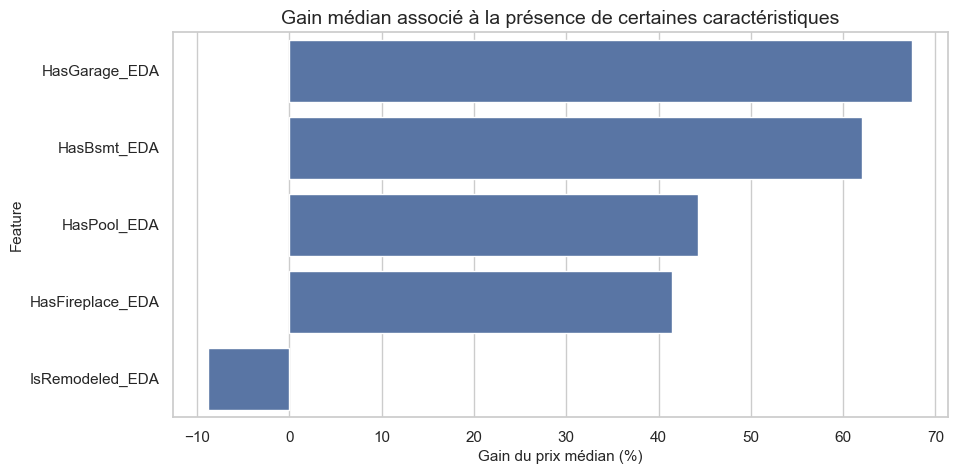

> **Interprétation :** Les flags simplifient l'information : au lieu de seulement connaître la surface du garage, on ajoute aussi une information binaire `HasGarage`. Cela aide certains modèles à comprendre la différence entre une valeur 0 structurelle et une petite surface réelle.

In [13]:
flag_cols = ['HasGarage_EDA', 'HasBsmt_EDA', 'HasFireplace_EDA', 'HasPool_EDA', 'IsRemodeled_EDA']

# Résumé détaillé : pour chaque flag, on compare les maisons avec valeur 0 et valeur 1.
flag_rows = []
for col in flag_cols:
    grouped = eda.groupby(col)[TARGET].agg(['count', 'median', 'mean']).reset_index()
    for _, row in grouped.iterrows():
        flag_rows.append({
            'feature': col,
            'value': int(row[col]),
            'count': int(row['count']),
            'median': row['median'],
            'mean': row['mean']
        })

flag_summary = pd.DataFrame(flag_rows)
display(flag_summary.round(0))

# Effet relatif : combien gagne-t-on en prix médian quand le flag passe de 0 à 1 ?
flag_medians = []
for col in flag_cols:
    med = eda.groupby(col)[TARGET].median()
    if 0 in med.index and 1 in med.index:
        flag_medians.append({
            'feature': col,
            'median_absent': med.loc[0],
            'median_present': med.loc[1],
            'gain_%': 100 * (med.loc[1] / med.loc[0] - 1) if med.loc[0] > 0 else np.nan
        })

flag_effect = pd.DataFrame(flag_medians).sort_values('gain_%', ascending=False)
display(flag_effect.round(2))

plt.figure(figsize=(10, 5))
sns.barplot(data=flag_effect, y='feature', x='gain_%')
plt.title('Gain médian associé à la présence de certaines caractéristiques')
plt.xlabel('Gain du prix médian (%)')
plt.ylabel('Feature')
plt.show()

interpretation(
    "Les flags simplifient l'information : au lieu de seulement connaître la surface du garage, on ajoute aussi une information binaire `HasGarage`. "
    "Cela aide certains modèles à comprendre la différence entre une valeur 0 structurelle et une petite surface réelle."
)

## 13. Analyse des outliers utilisés dans le pipeline

Le pipeline de modélisation supprime seulement quelques lignes très suspectes.  
L'objectif n'est pas de supprimer toutes les maisons chères, mais de retirer les points incohérents.

Nombre de lignes marquées comme outliers par le pipeline : 3


,Id,GrLivArea,LotArea,OverallQual,SalePrice
313,314,2036,215245,7,375000
523,524,4676,40094,10,184750
1298,1299,5642,63887,10,160000


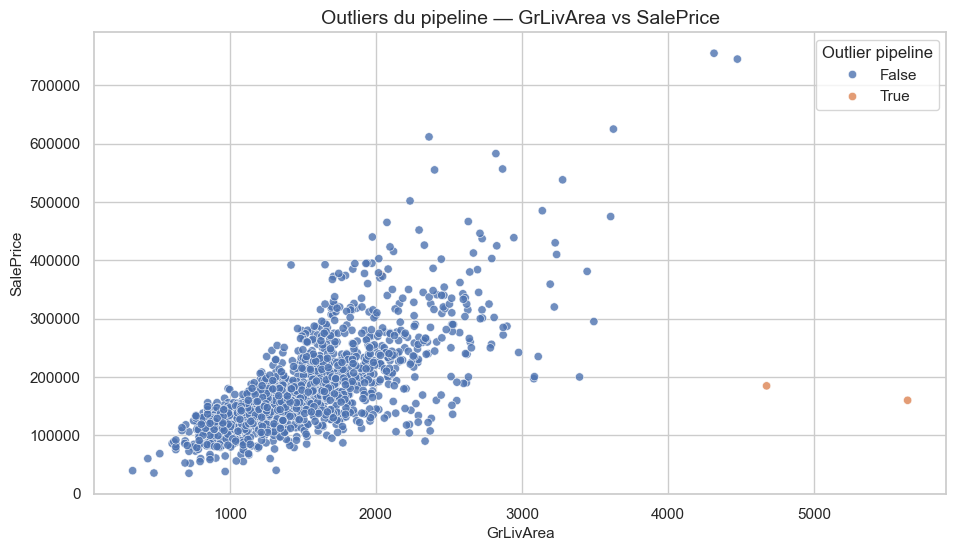

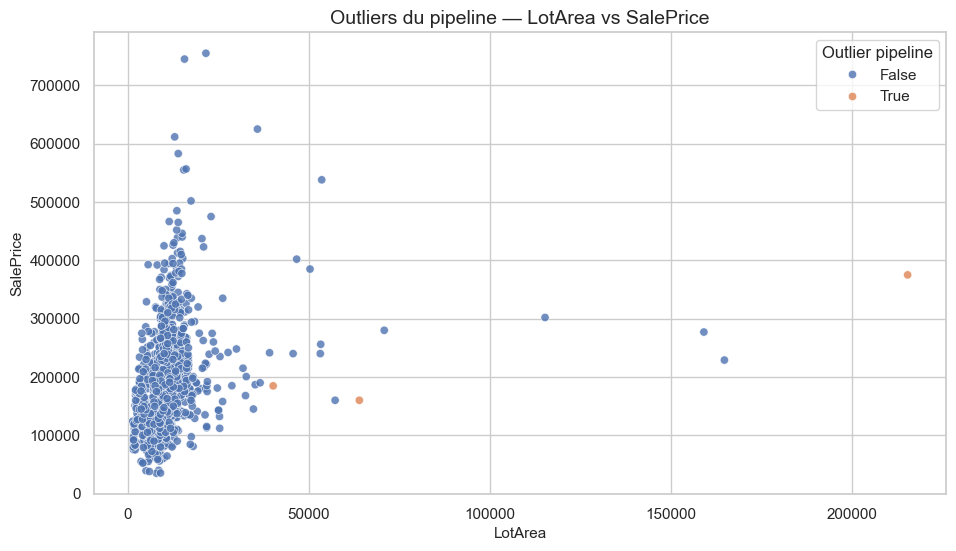

> **Interprétation :** Le pipeline retire **3 lignes**. C'est une suppression ciblée et prudente. Ces points peuvent créer une relation artificiellement mauvaise entre surface et prix, ce qui pénalise les modèles.

In [14]:
outlier_mask = (
    ((train_raw['GrLivArea'] > 4000) & (train_raw[TARGET] < 300_000)) |
    ((train_raw['LotArea'] > 200_000)) |
    ((train_raw['OverallQual'] <= 2) & (train_raw[TARGET] > 200_000))
)

outliers = train_raw.loc[outlier_mask, ['Id', 'GrLivArea', 'LotArea', 'OverallQual', TARGET]].copy()
print('Nombre de lignes marquées comme outliers par le pipeline :', int(outlier_mask.sum()))
display(outliers)

plt.figure(figsize=(11, 6))
sns.scatterplot(data=train_raw, x='GrLivArea', y=TARGET, hue=outlier_mask, alpha=0.8)
plt.title('Outliers du pipeline — GrLivArea vs SalePrice')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.legend(title='Outlier pipeline')
plt.show()

plt.figure(figsize=(11, 6))
sns.scatterplot(data=train_raw, x='LotArea', y=TARGET, hue=outlier_mask, alpha=0.8)
plt.title('Outliers du pipeline — LotArea vs SalePrice')
plt.xlabel('LotArea')
plt.ylabel('SalePrice')
plt.legend(title='Outlier pipeline')
plt.show()

interpretation(
    f"Le pipeline retire **{int(outlier_mask.sum())} lignes**. C'est une suppression ciblée et prudente. "
    "Ces points peuvent créer une relation artificiellement mauvaise entre surface et prix, ce qui pénalise les modèles."
)

## 14. Comparaison train vs test

Un bon modèle suppose que le test ressemble suffisamment au train.  
On vérifie rapidement les distributions de quelques variables importantes.

,variable,train_median,test_median,diff_median,diff_normalisée_IQR,KS_stat,KS_pvalue
5,YearRemodAdd,"1,994.000","1,992.000",-2.000,0.054,0.037,0.258
1,GrLivArea,"1,464.000","1,432.000",-32.000,0.049,0.046,0.082
6,LotArea,"9,478.500","9,399.000",-79.500,0.020,0.037,0.256
2,TotalBsmtSF,991.500,988.000,-3.500,0.007,0.041,0.160
3,GarageArea,480.000,480.000,0.000,0.000,0.025,0.759
0,OverallQual,6.000,6.000,0.000,0.000,0.022,0.854
4,YearBuilt,"1,973.000","1,973.000",0.000,0.000,0.015,0.995
7,FullBath,2.000,2.000,0.000,0.000,0.004,1.000


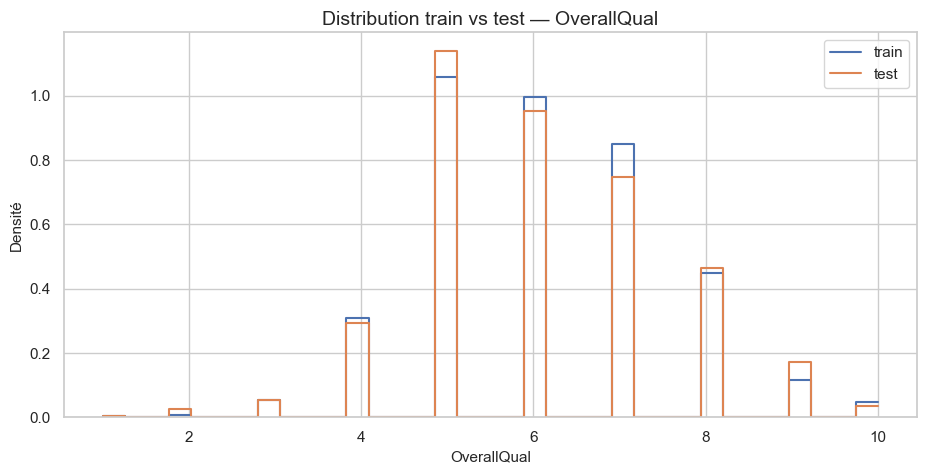

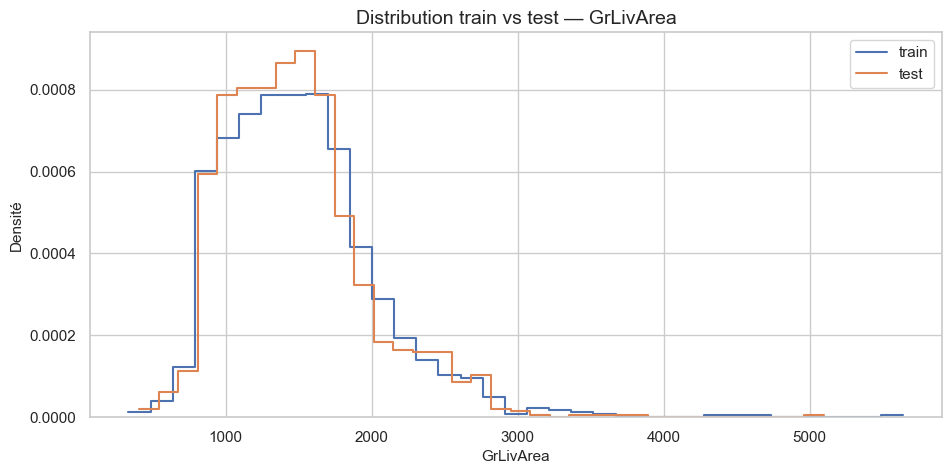

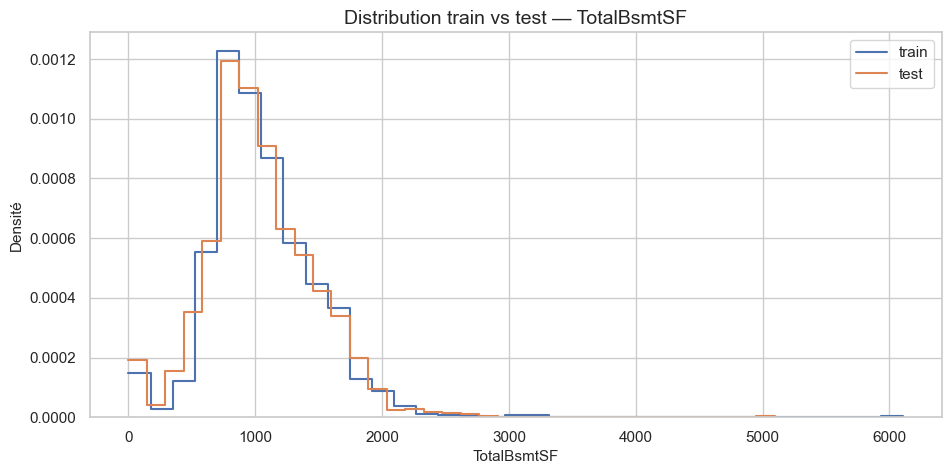

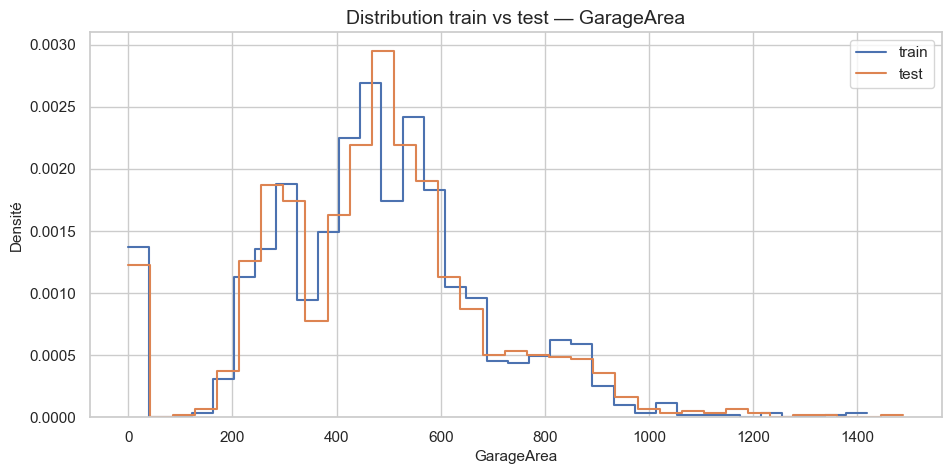

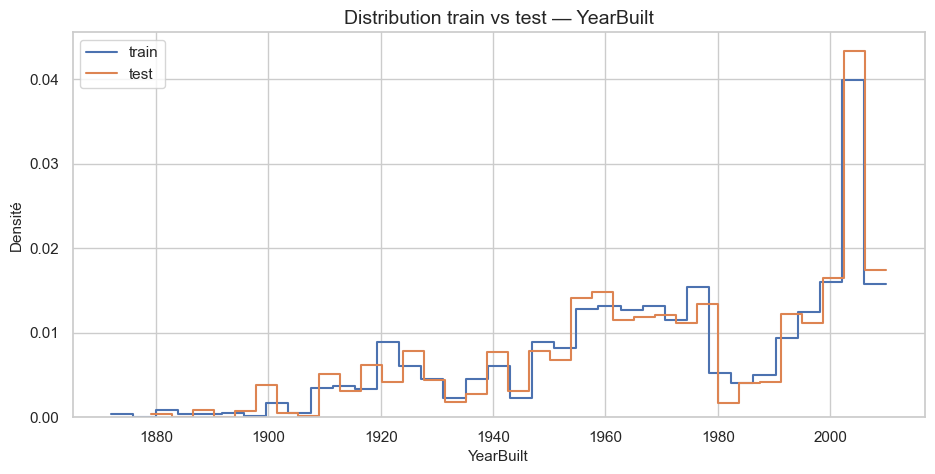

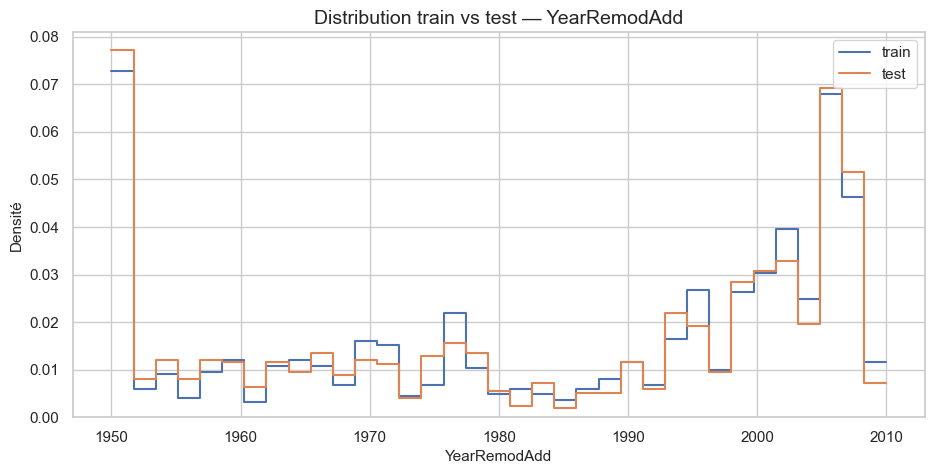

> **Interprétation :** La variable avec le plus grand écart médian normalisé parmi cette sélection est **YearRemodAdd**. Cette comparaison sert à détecter un éventuel décalage train/test. Si les distributions sont proches, la validation croisée est plus fiable.

In [15]:
important_numeric = [
    'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageArea',
    'YearBuilt', 'YearRemodAdd', 'LotArea', 'FullBath'
]
important_numeric = [c for c in important_numeric if c in train_raw.columns and c in test_raw.columns]

shift_rows = []
for col in important_numeric:
    train_median = train_raw[col].median()
    test_median = test_raw[col].median()
    train_iqr = train_raw[col].quantile(0.75) - train_raw[col].quantile(0.25)
    normalized_diff = abs(train_median - test_median) / train_iqr if train_iqr != 0 else np.nan
    try:
        ks_stat, ks_p = stats.ks_2samp(train_raw[col].dropna(), test_raw[col].dropna())
    except Exception:
        ks_stat, ks_p = np.nan, np.nan
    shift_rows.append({
        'variable': col,
        'train_median': train_median,
        'test_median': test_median,
        'diff_median': test_median - train_median,
        'diff_normalisée_IQR': normalized_diff,
        'KS_stat': ks_stat,
        'KS_pvalue': ks_p
    })

shift_table = pd.DataFrame(shift_rows).sort_values('diff_normalisée_IQR', ascending=False)
display(shift_table.round(4))

for col in important_numeric[:6]:
    plt.figure(figsize=(11, 5))
    sns.histplot(train_raw[col].dropna(), label='train', stat='density', bins=35, element='step', fill=False)
    sns.histplot(test_raw[col].dropna(), label='test', stat='density', bins=35, element='step', fill=False)
    plt.title(f'Distribution train vs test — {col}')
    plt.xlabel(col)
    plt.ylabel('Densité')
    plt.legend()
    plt.show()

most_shifted = shift_table.iloc[0]['variable'] if len(shift_table) else 'aucune variable'
interpretation(
    f"La variable avec le plus grand écart médian normalisé parmi cette sélection est **{most_shifted}**. "
    "Cette comparaison sert à détecter un éventuel décalage train/test. Si les distributions sont proches, la validation croisée est plus fiable."
)

## 15. Synthèse EDA — ce qu'on apprend pour le pipeline

Cette section résume les décisions importantes pour les notebooks suivants.

In [16]:
top_corr_features = corr_saleprice.head(8).index.tolist()
missing_cols_key = missing_compare.head(8).index.tolist() if not missing_compare.empty else []

synthese = f"""
### Synthèse principale

1. **La cible `SalePrice` est asymétrique.**  
   La transformation `log1p(SalePrice)` est justifiée, car la skewness passe de **{skew_raw:.3f}** à **{skew_log:.3f}**.

2. **Les variables numériques les plus importantes sont :**  
   `{', '.join(top_corr_features)}`.

3. **Les valeurs manquantes ne sont pas toutes des erreurs.**  
   Les colonnes les plus manquantes incluent : `{', '.join(missing_cols_key)}`.  
   Plusieurs `NaN` signifient probablement absence de garage, sous-sol, piscine, cheminée, etc.

4. **Le quartier est un signal très fort.**  
   Les prix médians changent fortement selon `Neighborhood`, donc l'encodage catégoriel est crucial.

5. **Les features agrégées sont utiles.**  
   Des variables comme `TotalSF`, `TotalBathrooms`, `HouseAge`, `HasGarage`, `HasBsmt` résument mieux l'information métier.

6. **Les outliers sont traités prudemment.**  
   Le pipeline retire seulement **{int(outlier_mask.sum())} lignes** très suspectes, au lieu de supprimer massivement les valeurs extrêmes.

### Conséquence pour les prochains notebooks

- Notebook 02 : imputations adaptées au sens métier des `NaN`.  
- Notebook 03 : création de features de surface, qualité, âge, flags et interactions.  
- Notebook 04 : modèles régularisés + modèles boosting + blending/stacking pour exploiter des relations linéaires et non linéaires.
"""

display(Markdown(synthese))


### Synthèse principale

1. **La cible `SalePrice` est asymétrique.**  
   La transformation `log1p(SalePrice)` est justifiée, car la skewness passe de **1.883** à **0.121**.

2. **Les variables numériques les plus importantes sont :**  
   `OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, FullBath, TotRmsAbvGrd`.

3. **Les valeurs manquantes ne sont pas toutes des erreurs.**  
   Les colonnes les plus manquantes incluent : `PoolQC, MiscFeature, Alley, Fence, MasVnrType, FireplaceQu, LotFrontage, GarageType`.  
   Plusieurs `NaN` signifient probablement absence de garage, sous-sol, piscine, cheminée, etc.

4. **Le quartier est un signal très fort.**  
   Les prix médians changent fortement selon `Neighborhood`, donc l'encodage catégoriel est crucial.

5. **Les features agrégées sont utiles.**  
   Des variables comme `TotalSF`, `TotalBathrooms`, `HouseAge`, `HasGarage`, `HasBsmt` résument mieux l'information métier.

6. **Les outliers sont traités prudemment.**  
   Le pipeline retire seulement **3 lignes** très suspectes, au lieu de supprimer massivement les valeurs extrêmes.

### Conséquence pour les prochains notebooks

- Notebook 02 : imputations adaptées au sens métier des `NaN`.  
- Notebook 03 : création de features de surface, qualité, âge, flags et interactions.  
- Notebook 04 : modèles régularisés + modèles boosting + blending/stacking pour exploiter des relations linéaires et non linéaires.


## 16. Conclusion

Cette EDA montre que le problème n'est pas seulement statistique : il est aussi métier.

Une maison chère est généralement expliquée par une combinaison de facteurs :

- qualité générale ;
- surface totale ;
- quartier ;
- garage/sous-sol ;
- âge et rénovation ;
- qualité de la cuisine, de l'extérieur et du sous-sol.

Donc la meilleure stratégie n'est pas seulement d'entraîner beaucoup de modèles.  
Il faut d'abord construire des features qui représentent correctement la valeur réelle d'une maison.